
*Laboratorio en Ciencia de Datos*


---



#**Trabajo Practico Final**



---



# Introducción

El presente trabajo práctico tiene como objetivo segmentar la base de clientes de una plataforma de comercio electrónico con operaciones en el Reino Unido, con el fin de identificar perfiles diferenciados que permitan al equipo de marketing personalizar su estrategia de comunicación y dejar de enviar las mismas campañas a todos los clientes por igual.

Para ello se utilizará el dataset **Online Retail II**, disponible públicamente en el UCI Machine Learning Repository. El mismo contiene todas las transacciones realizadas por la plataforma durante los años 2010 y 2011, sumando aproximadamente 500.000 registros.

---

### Estructura del dataset

Es importante destacar que **cada fila del dataset no representa un cliente ni una compra completa, sino una línea de producto dentro de una factura**. Esto significa que una sola compra puede estar compuesta por múltiples filas, una por cada producto adquirido.

El dataset cuenta con 8 variables:

| Variable | Descripción |
|---|---|
| `InvoiceNo` | Identificador único de la factura. Si comienza con la letra `'C'` indica que la transacción fue cancelada |
| `StockCode` | Código interno del producto |
| `Description` | Nombre o descripción del producto |
| `Quantity` | Cantidad de unidades compradas en esa línea. Valores negativos indican devoluciones |
| `InvoiceDate` | Fecha y hora exacta de la transacción |
| `UnitPrice` | Precio unitario del producto expresado en libras esterlinas (£) |
| `CustomerID` | Identificador único del cliente. Presenta valores nulos en una porción considerable de los registros |
| `Country` | País desde el cual se realizó la compra |

---

### Consideraciones iniciales

El dataset se encuentra en su estado crudo, tal como existe en producción, por lo que presenta varios problemas de calidad que deberán ser tratados antes del análisis:

- Registros sin `CustomerID` que no pueden asociarse a ningún cliente
- Facturas canceladas identificadas por el prefijo `'C'` en `InvoiceNo`
- Valores negativos o nulos en `Quantity` y `UnitPrice`

Dado que el problema es de **aprendizaje no supervisado**, el dataset no cuenta con ninguna variable objetivo ni etiquetas predefinidas. El objetivo es descubrir la estructura natural que existe en los datos y traducirla en segmentos accionables para el negocio.






# Preparación del dataset

##Carga y descripción del dataset

In [8]:
# Librerías generales
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')
from sklearn.datasets import fetch_openml


# Visualización
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Lectura de archivos
import openpyxl

# Preprocesamiento
from scipy.stats import mstats
from sklearn.preprocessing import RobustScaler, MinMaxScaler

# Modelos de clustering
from sklearn.cluster import KMeans, DBSCAN

# Métricas
from sklearn.metrics import silhouette_score

from matplotlib.patches import FancyArrowPatch
import matplotlib.patches as mpatches




In [9]:
url = "https://github.com/TomasBattel/customer-segmentation-retail/raw/main/Online%20Retail.xlsx"
retail = pd.read_excel(url, engine='openpyxl')

In [10]:
retail.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [11]:
retail.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


## Eliminación de filas duplicadas


In [12]:
retail.duplicated().sum()

np.int64(5268)

In [13]:
total_duplicados = retail.duplicated().sum()
print(f"Hay {total_duplicados} filas completamente duplicadas.")

Hay 5268 filas completamente duplicadas.


In [14]:
print("Retail antes de eliminar duplicados:")
print(retail.shape)
retail.drop_duplicates(inplace=True)
print("Retail después de eliminar duplicados:")
print(retail.shape)

Retail antes de eliminar duplicados:
(541909, 8)
Retail después de eliminar duplicados:
(536641, 8)


##Elementos nulos

In [15]:
retail.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135037
Country,0


- `Description`

Contiene 1.454 valores nulos. Consideramos **eliminar** esta variable ya que descripción del producto no aporta información relevante para caracterizar el comportamiento de compra de un cliente.

In [16]:
retail_cured = retail.drop(columns=['Description'])
print("Columna Description eliminada")
print(f"Columnas restantes: {list(retail_cured.columns)}")

Columna Description eliminada
Columnas restantes: ['InvoiceNo', 'StockCode', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']


- `CustomerID`

Al analizar los valores nulos encontramos que 135.037 registros no cuentan con un identificador de cliente, lo que representa aproximadamente el 25% del dataset original. Ante esto, debatimos dos alternativas posibles:

La primera opción era agrupar todos estos registros bajo un ID ficticio, tratándolos como un único perfil de "cliente anónimo". Sin embargo, descartamos esta idea ya que estaríamos mezclando el comportamiento de miles de personas distintas como si fueran una sola, lo cual no tendría ningún valor analítico real. Además, desde el punto de vista del negocio, el equipo de marketing no tendría forma de contactar a estos clientes, ya que no dejaron ningún dato de contacto al momento de la compra.

La segunda opción, que fue la que decidimos adoptar, fue **eliminar** estos registros del análisis. Sin el identificador de cliente no es posible construir un perfil individual de comportamiento de compra, que es justamente el objetivo del trabajo.

Reconocemos que esta decisión implica una limitación: los segmentos que construiremos representan únicamente a los clientes registrados en la plataforma, dejando fuera aproximadamente 1 de cada 4 transacciones.


In [17]:
filas_antes = len(retail_cured)

retail_cured = retail_cured.dropna(subset=['CustomerID'])

filas_eliminadas = filas_antes - len(retail_cured)
porcentaje = (filas_eliminadas / filas_antes) * 100

print(f"Filas antes:     {filas_antes}")
print(f"Filas eliminadas: {filas_eliminadas} ({porcentaje:.1f}%)")
print(f"Filas restantes:  {len(retail_cured)}")

Filas antes:     536641
Filas eliminadas: 135037 (25.2%)
Filas restantes:  401604


##Registros problemáticos

In [18]:
# Cancelaciones (facturas que empiezan con 'C')
cancelaciones = retail_cured['InvoiceNo'].astype(str).str.startswith('C').sum()

# Cantidades
cantidad_cero = (retail_cured['Quantity'] == 0).sum()
cantidad_negativa = (retail_cured['Quantity'] < 0).sum()

# Precios
precio_cero = (retail_cured['UnitPrice'] == 0).sum()
precio_negativo = (retail_cured['UnitPrice'] < 0).sum()

total = len(retail_cured)

# Suma de todos los registros problemáticos individuales (excluyendo duplicados si hay solapamiento)
total_registros_problematicos = cancelaciones + cantidad_cero + cantidad_negativa + precio_cero + precio_negativo

print("=" * 45)
print("        RESUMEN DE DATOS PROBLEMÁTICOS")
print("=" * 45)
print(f"Total de filas analizadas:       {total:>10,}")
print("-" * 45)
print(f"Facturas canceladas (C...):      {cancelaciones:>10,} ({cancelaciones/total*100:.1f}%)")
print("-" * 45)
print(f"Cantidades iguales a cero:       {cantidad_cero:>10,} ({cantidad_cero/total*100:.1f}%)")
print(f"Cantidades negativas:            {cantidad_negativa:>10,} ({cantidad_negativa/total*100:.1f}%)")
print("-" * 45)
print(f"Precios iguales a cero:          {precio_cero:>10,} ({precio_cero/total*100:.1f}%)")
print(f"Precios negativos:               {precio_negativo:>10,} ({precio_negativo/total*100:.1f}%)")
print("-" * 45)
print(f"Total de registros problemáticos: {total_registros_problematicos:>10,}")
print("=" * 45)

        RESUMEN DE DATOS PROBLEMÁTICOS
Total de filas analizadas:          401,604
---------------------------------------------
Facturas canceladas (C...):           8,872 (2.2%)
---------------------------------------------
Cantidades iguales a cero:                0 (0.0%)
Cantidades negativas:                 8,872 (2.2%)
---------------------------------------------
Precios iguales a cero:                  40 (0.0%)
Precios negativos:                        0 (0.0%)
---------------------------------------------
Total de registros problemáticos:     17,784


In [19]:
print(f"Precios iguales a cero: {(retail_cured['UnitPrice'] == 0).sum()}")
print(f"Precios negativos: {(retail_cured['UnitPrice'] < 0).sum()}")
print(f"Cantidades iguales a cero: {(retail_cured['Quantity'] == 0).sum()}")
print(f"Cantidades negativas: {(retail_cured['Quantity'] < 0).sum()}")

Precios iguales a cero: 40
Precios negativos: 0
Cantidades iguales a cero: 0
Cantidades negativas: 8872


- Facturas canceladas: identificadas por el prefijo 'C' en la columna InvoiceNo. Representan transacciones que fueron anuladas y por lo tanto no reflejan una compra real. Incluirlas inflaría artificialmente el historial de compras de los clientes.

- Cantidades negativas: corresponden a devoluciones de productos. Al igual que las cancelaciones, no representan una compra efectiva y distorsionarían el gasto real de cada cliente.

- Precios iguales a cero: probablemente corresponden a muestras gratuitas o ajustes internos del sistema. Al no representar una transacción comercial real, decidimos excluirlos.



In [20]:
filas_antes = len(retail_cured)

retail_cured = retail_cured[~retail_cured['InvoiceNo'].astype(str).str.startswith('C')]

filas_eliminadas = filas_antes - len(retail_cured)
porcentaje = (filas_eliminadas / filas_antes) * 100

print(f"Filas antes:                {filas_antes:>10,}")
print(f"Cancelaciones eliminadas:   {filas_eliminadas:>10,} ({porcentaje:.1f}%)")
print(f"Filas restantes:            {len(retail_cured):>10,}")

Filas antes:                   401,604
Cancelaciones eliminadas:        8,872 (2.2%)
Filas restantes:               392,732


In [21]:
retail_cured = retail_cured[retail_cured['Quantity'] > 0]
retail_cured = retail_cured[retail_cured['UnitPrice'] > 0]


In [22]:
print("=" * 50)
print("     VERIFICACIÓN POST LIMPIEZA")
print("=" * 50)
print(f"Facturas canceladas (C...):  {retail_cured['InvoiceNo'].astype(str).str.startswith('C').sum():>10,}")
print(f"Cantidades negativas:        {(retail_cured['Quantity'] < 0).sum():>10,}")
print(f"Cantidades cero:             {(retail_cured['Quantity'] == 0).sum():>10,}")
print(f"Precios negativos:           {(retail_cured['UnitPrice'] < 0).sum():>10,}")
print(f"Precios cero:                {(retail_cured['UnitPrice'] == 0).sum():>10,}")
print(f"CustomerID nulos:            {retail_cured['CustomerID'].isnull().sum():>10,}")
print("=" * 50)

     VERIFICACIÓN POST LIMPIEZA
Facturas canceladas (C...):           0
Cantidades negativas:                 0
Cantidades cero:                      0
Precios negativos:                    0
Precios cero:                         0
CustomerID nulos:                     0


##Creación de variables

###Precio_final

Consideramos necesario crear la variable `PRECIO_FINAL` ya que el dataset no cuenta con una columna que refleje directamente el valor económico de cada línea de compra. Si bien contamos con el precio unitario de cada producto (`UnitPrice`) y la cantidad de unidades compradas (`Quantity`), ninguna de estas variables por sí sola nos dice cuánto se gastó realmente en esa línea.


In [23]:
retail_cured['PRECIO_FINAL'] = retail_cured['Quantity'] * retail_cured['UnitPrice']

In [24]:
retail_cured.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID,PRECIO_FINAL
count,392692.000000,392692,392692.000000,392692.000000,392692.000000
mean,13.119702,2011-07-10 19:13:07.771892480,3.125914,15287.843865,22.631500
min,1.000000,2010-12-01 08:26:00,0.001000,12346.000000,0.001000
25%,2.000000,2011-04-07 11:12:00,1.250000,13955.000000,4.950000
50%,6.000000,2011-07-31 12:02:00,1.950000,15150.000000,12.450000
75%,12.000000,2011-10-20 12:53:00,3.750000,16791.000000,19.800000
max,80995.000000,2011-12-09 12:50:00,8142.750000,18287.000000,168469.600000
std,180.492832,NaN,22.241836,1713.539549,311.099224


### Clientes internacionales

In [25]:
# Clientes únicos por país
clientes_por_pais = retail_cured.groupby('Country')['CustomerID'].nunique().sort_values(ascending=False)
print(clientes_por_pais)

# Porcentaje de clientes internacionales vs locales
total_clientes = retail_cured['CustomerID'].nunique()
clientes_uk = retail_cured[retail_cured['Country'] == 'United Kingdom']['CustomerID'].nunique()
clientes_internacionales = total_clientes - clientes_uk

print(f"\nClientes UK: {clientes_uk} ({clientes_uk/total_clientes*100:.1f}%)")
print(f"Clientes internacionales: {clientes_internacionales} ({clientes_internacionales/total_clientes*100:.1f}%)")

Country
United Kingdom          3920
Germany                   94
France                    87
Spain                     30
Belgium                   25
Switzerland               21
Portugal                  19
Italy                     14
Finland                   12
Austria                   11
Norway                    10
Australia                  9
Denmark                    9
Netherlands                9
Channel Islands            9
Japan                      8
Sweden                     8
Cyprus                     8
Poland                     6
Unspecified                4
USA                        4
Canada                     4
Greece                     4
Israel                     3
EIRE                       3
United Arab Emirates       2
Bahrain                    2
Malta                      2
Brazil                     1
Lebanon                    1
Iceland                    1
Czech Republic             1
European Community         1
Saudi Arabia               1
RSA   

In [26]:
# ¿Cómo se distribuyen esos 418 clientes internacionales entre países?
retail_cured[retail_cured['Country'] != 'United Kingdom'].groupby('Country')['CustomerID'].nunique().sort_values(ascending=False).head(10)

,CustomerID
Country,
Germany,94
France,87
Spain,30
Belgium,25
Switzerland,21
Portugal,19
Italy,14
Finland,12
Austria,11


Nos pareció interesante evaluar la posibilidad de crear una variable `es_internacional` que identificara si un cliente pertenece al mercado local del Reino Unido o si opera desde otro país. Consideramos que esta información podría ser valiosa para el equipo de marketing a la hora de diseñar campañas diferenciadas.

Sin embargo, al explorar los datos encontramos que el 90.4% de los clientes son del Reino Unido (3.921 clientes) y apenas el 9.6% son internacionales (418 clientes). Además, al analizar cómo se distribuyen esos 418 clientes internacionales, observamos que si bien están concentrados principalmente en Alemania (94) y Francia (88), el volumen por país es demasiado bajo como para formar segmentos propios y significativos.

Por estas razones **decidimos no crear la variable**, ya que con tan pocos clientes internacionales es probable que el algoritmo de clustering los absorba dentro de los segmentos de comportamiento sin distinguirlos por origen geográfico.

##Perfil del cliente

Hasta este punto trabajamos sobre `retail_cured`, un dataset donde cada fila representa una línea de producto dentro de una factura. Un cliente que realizó 10 compras a lo largo del año puede aparecer en cientos de filas distintas — una por cada producto de cada factura.

**No podemos clusterizar filas, necesitamos clusterizar personas.** Para eso colapsamos todo el historial de transacciones en una única fila por cliente, construyendo variables que resumen su comportamiento de compra a lo largo de todo el período.

Las cinco variables que construiremos responden las preguntas de negocio más importantes que el equipo de marketing puede hacerse sobre un cliente:
>
> | Pregunta | Variable |
> |---|---|
> | ¿Sigue activo o se fue? | `DIAS_ULTIMA_COMPRA` |
> | ¿Es fiel o compró una sola vez? | `CANT_FACTURAS` |
> | ¿Vale la pena retenerlo? | `GASTO_TOTAL` |
> | ¿Compra caro o barato por visita? | `TICKET_PROMEDIO` |
> | ¿Explora el catálogo o se concentra en pocos productos? | `PRODUCTOS_DISTINTOS` |

Para ello agrupamos todas las transacciones por `CustomerID` y construimos cinco variables que capturan las dimensiones más relevantes del comportamiento de compra:

- **`DIAS_ULTIMA_COMPRA`:** cantidad de días transcurridos entre la última compra del cliente y la fecha más reciente del dataset. Nos indica qué tan reciente es su actividad.

- **`CANT_FACTURAS`:** cantidad de facturas únicas realizadas por el cliente a lo largo de todo su historial. Nos indica con qué frecuencia compra.

- **`GASTO_TOTAL`:** suma de todos los montos gastados por el cliente en el período analizado. Nos indica cuánto dinero aportó a la plataforma.

Las tres variables anteriores conforman el modelo **RFM** (Recencia, Frecuencia, Monto), un enfoque clásico de segmentación de clientes ampliamente utilizado en e-commerce y retail.
Sin embargo, RFM por sí solo no distingue, por ejemplo, entre un cliente que gasta mucho en pocas compras grandes y otro que acumula ese mismo gasto en muchas compras pequeñas, ni entre un cliente fiel a pocos productos y uno que explora toda la oferta del catálogo.

Por eso incorporamos dos variables adicionales:

- **`TICKET_PROMEDIO`:** gasto promedio por factura. Nos permite identificar si el cliente
realiza compras de alto valor unitario o si su gasto total proviene de muchas transacciones
pequeñas. Esta variable se calcula primero sumando el gasto por factura y luego promediando
por cliente, para no confundirla con el precio promedio por línea de producto.

- **`PRODUCTOS_DISTINTOS`:** cantidad de productos únicos (StockCodes distintos) comprados
a lo largo de todo su historial. Nos indica si el cliente tiene un comportamiento de compra
variado o si se concentra en pocos artículos específicos.

Como resultado de esta transformación, pasamos de **392.692 filas** de transacciones a una tabla de **4.338 clientes únicos**, donde cada fila representa el perfil completo de un cliente con sus cinco dimensiones de comportamiento, y será la base para el análisis de
segmentación.


In [27]:
# Fecha de referencia: el día más reciente del dataset
fecha_referencia = retail_cured['InvoiceDate'].max()

# Ticket promedio: primero sumamos por factura, luego promediamos por cliente
gasto_por_factura = (
    retail_cured
    .groupby(['CustomerID', 'InvoiceNo'])['PRECIO_FINAL']
    .sum()
    .reset_index()
)

ticket_promedio = (
    gasto_por_factura
    .groupby('CustomerID')['PRECIO_FINAL']
    .mean()
    .reset_index()
    .rename(columns={'PRECIO_FINAL': 'TICKET_PROMEDIO'})
)

# Perfil principal con RFM + productos distintos
perfil_clientes = retail_cured.groupby('CustomerID').agg(
    DIAS_ULTIMA_COMPRA  = ('InvoiceDate',  lambda x: (fecha_referencia - x.max()).days),
    CANT_FACTURAS       = ('InvoiceNo',    'nunique'),
    GASTO_TOTAL         = ('PRECIO_FINAL', 'sum'),
    PRODUCTOS_DISTINTOS = ('StockCode',    'nunique')
).reset_index()

# Incorporar ticket promedio
perfil_clientes = perfil_clientes.merge(ticket_promedio, on='CustomerID', how='left')

n_transacciones = len(retail_cured)
n_clientes = len(perfil_clientes)

print(f"Filas de transacciones:  {n_transacciones:,}")
print(f"Perfiles de clientes:    {n_clientes:,}")
print(f"Variables del perfil:    {list(perfil_clientes.columns[1:])}")
print()
print(perfil_clientes.head(10))
print()
print(perfil_clientes.describe().round(2))

Filas de transacciones:  392,692
Perfiles de clientes:    4,338
Variables del perfil:    ['DIAS_ULTIMA_COMPRA', 'CANT_FACTURAS', 'GASTO_TOTAL', 'PRODUCTOS_DISTINTOS', 'TICKET_PROMEDIO']

   CustomerID  DIAS_ULTIMA_COMPRA  CANT_FACTURAS  GASTO_TOTAL  \
0     12346.0                 325              1     77183.60   
1     12347.0                   1              7      4310.00   
2     12348.0                  74              4      1797.24   
3     12349.0                  18              1      1757.55   
4     12350.0                 309              1       334.40   
5     12352.0                  35              8      2506.04   
6     12353.0                 203              1        89.00   
7     12354.0                 231              1      1079.40   
8     12355.0                 213              1       459.40   
9     12356.0                  22              3      2811.43   

   PRODUCTOS_DISTINTOS  TICKET_PROMEDIO  
0                    1     77183.600000  
1            

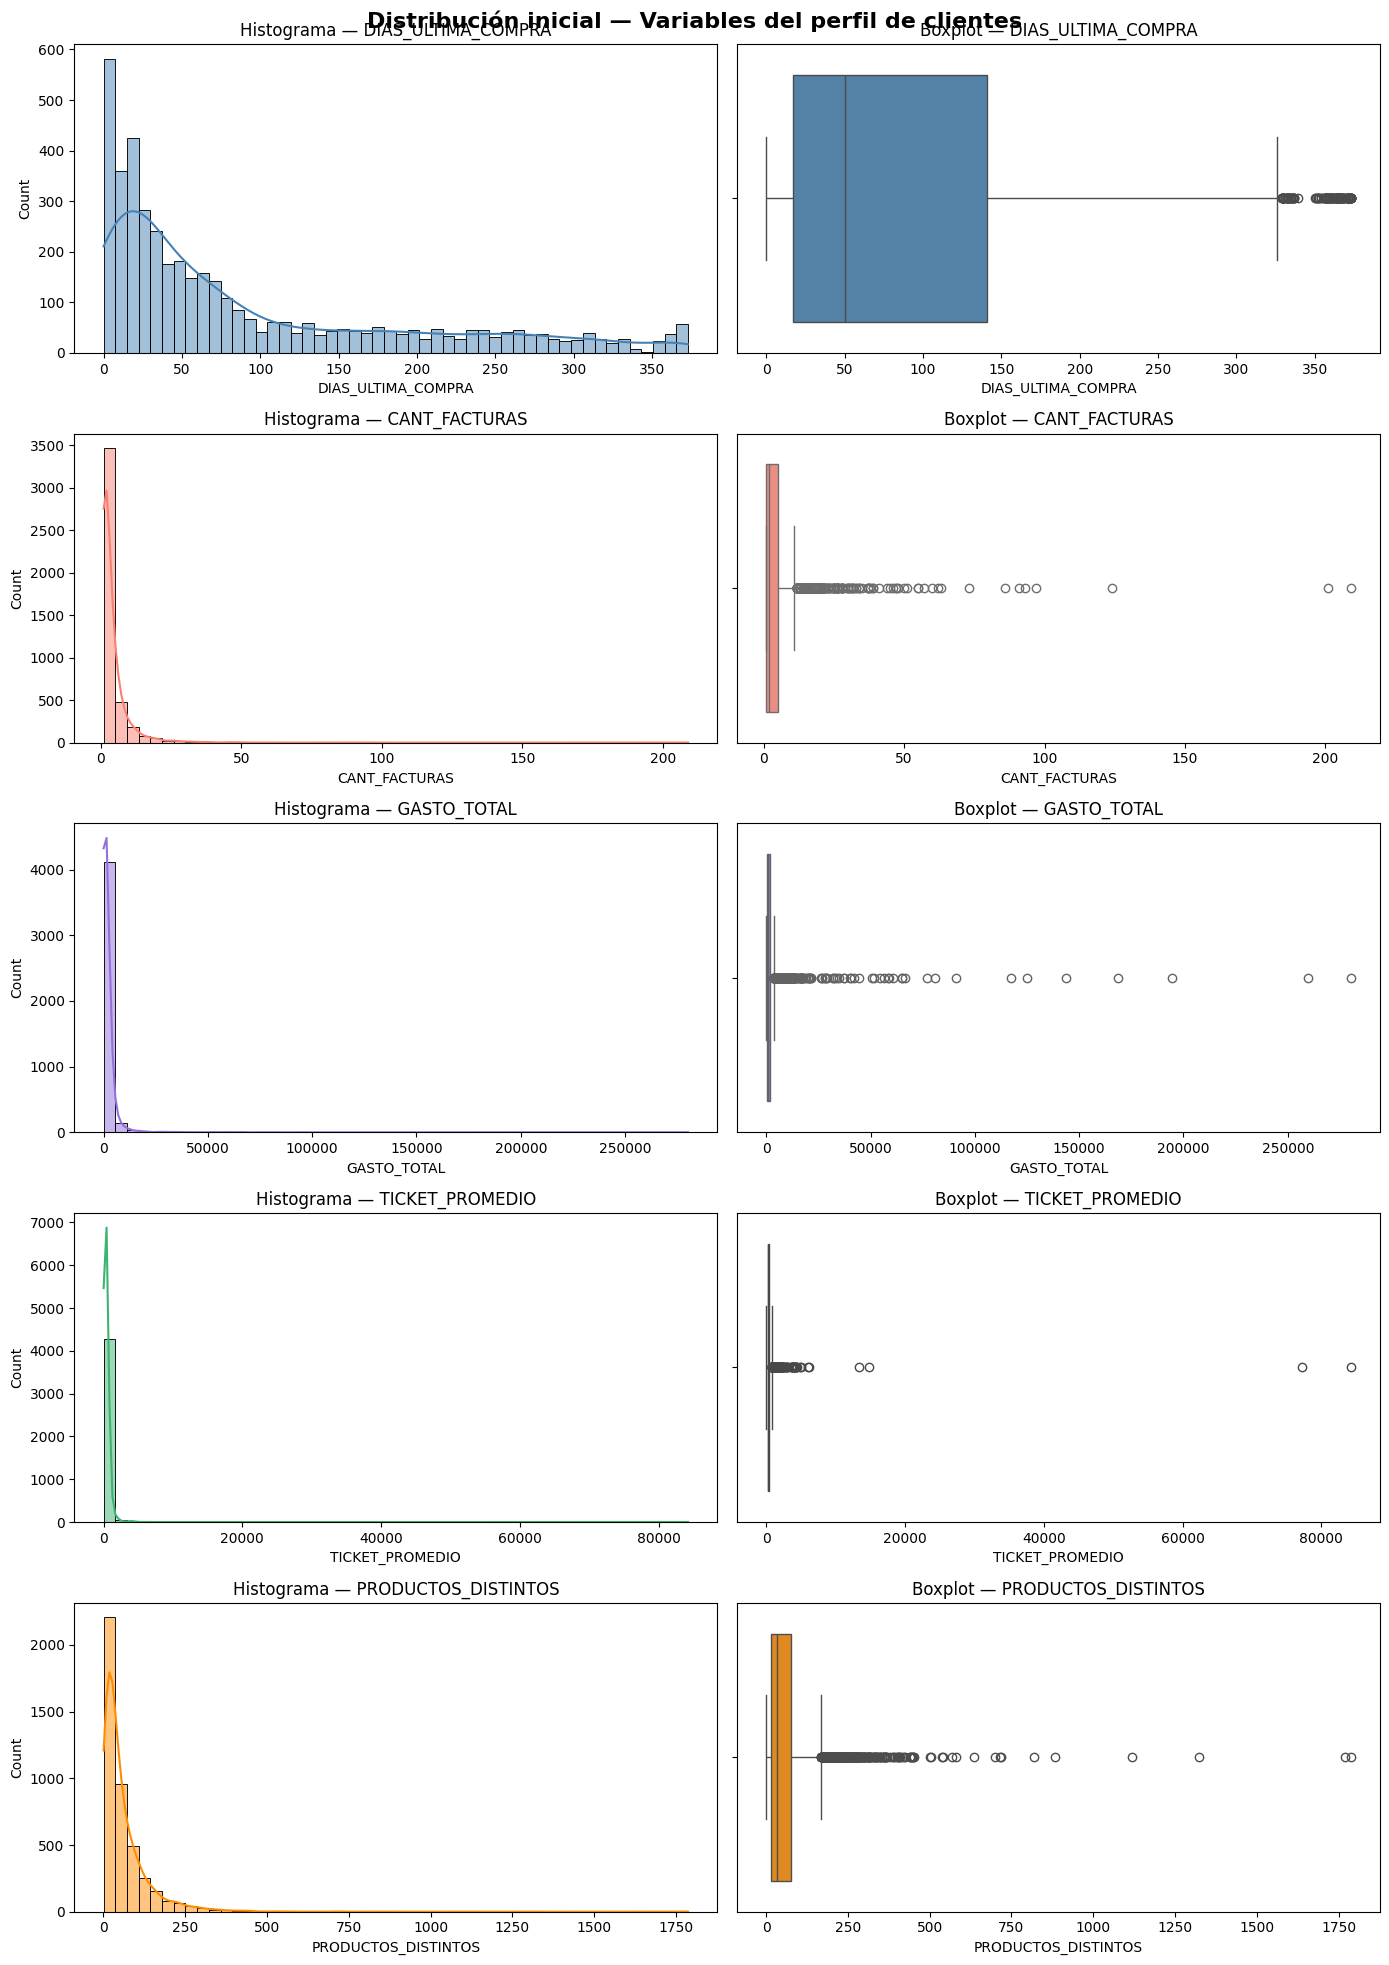

Estadísticas descriptivas del perfil:
       DIAS_ULTIMA_COMPRA  CANT_FACTURAS  GASTO_TOTAL  TICKET_PROMEDIO  \
count             4338.00        4338.00      4338.00          4338.00   
mean                91.54           4.27      2048.69           417.65   
std                100.01           7.70      8985.23          1796.51   
min                  0.00           1.00         3.75             3.45   
25%                 17.00           1.00       306.48           177.87   
50%                 50.00           2.00       668.57           291.94   
75%                141.00           5.00      1660.60           428.28   
max                373.00         209.00    280206.02         84236.25   

       PRODUCTOS_DISTINTOS  
count              4338.00  
mean                 61.50  
std                  85.37  
min                   1.00  
25%                  16.00  
50%                  35.00  
75%                  77.00  
max                1787.00  


In [28]:
## Análisis exploratorio del perfil de clientes

fig, axes = plt.subplots(5, 2, figsize=(14, 20))
fig.suptitle('Distribución inicial — Variables del perfil de clientes',
             fontsize=16, fontweight='bold')

cols_perfil = ['DIAS_ULTIMA_COMPRA', 'CANT_FACTURAS', 'GASTO_TOTAL',
               'TICKET_PROMEDIO', 'PRODUCTOS_DISTINTOS']
colors = ['steelblue', 'salmon', 'mediumpurple', 'mediumseagreen', 'darkorange']

for i, (col, color) in enumerate(zip(cols_perfil, colors)):
    sns.histplot(perfil_clientes[col], bins=50, ax=axes[i,0], color=color, kde=True)
    axes[i,0].set_title(f'Histograma — {col}')

    sns.boxplot(x=perfil_clientes[col], ax=axes[i,1], color=color)
    axes[i,1].set_title(f'Boxplot — {col}')

plt.tight_layout()
plt.show()

# Tabla de estadísticas descriptivas
print("Estadísticas descriptivas del perfil:")
print(perfil_clientes[cols_perfil].describe().round(2))

El perfil construido contiene **4.338 clientes únicos**. A continuación se describen las principales características de cada variable:

> **Recencia (`DIAS_ULTIMA_COMPRA`):** el cliente típico compró hace 50 días (mediana), pero la media sube a 91 días por una cola de clientes inactivos. El rango va de 0 a 373 días, lo que indica que conviven clientes que compraron ayer con clientes que llevan más de un año sin actividad. El 25% más activo compró en los últimos 17 días.
>
> **Frecuencia (`CANT_FACTURAS`):** la mitad de los clientes realizó apenas 2 facturas en todo el período, y el 75% no superó las 5. Sin embargo, la media es 4.27 y el máximo llega a 209, lo que revela la existencia de un grupo pequeño de compradores muy frecuentes que distorsiona la distribución hacia la derecha.
>
> **Gasto total (`GASTO_TOTAL`):** la mediana es £668 pero la media es £2.048, casi tres veces más alta. El máximo de £280.206 confirma la presencia de clientes mayoristas que operan en una escala completamente distinta al cliente típico. El 75% de los clientes gastó menos de £1.660 en todo el período.
>
> **Ticket promedio (`TICKET_PROMEDIO`):** el gasto por factura típico es £292 (mediana), pero con un desvío estándar de £1.796 y un máximo de £84.236, la distribución es extremadamente sesgada. Esto sugiere que algunos clientes realizan compras puntuales de altísimo valor.
>
> **Variedad de productos (`PRODUCTOS_DISTINTOS`):** la mitad de los clientes compró 35 productos distintos o menos, pero el promedio es 61 y el máximo llega a 1.787. El fuerte sesgo a la derecha indica que la mayoría de los clientes explora una porción acotada del catálogo, mientras que un grupo reducido cubre casi toda la oferta disponible.

En todas las variables se observa el mismo patrón: **distribuciones fuertemente asimétricas con colas largas a la derecha**, producto de la coexistencia de clientes individuales y compradores mayoristas en la misma base. Esta asimetría justifica el tratamiento de outliers y la transformación logarítmica que se aplica en la siguiente sección.


###Tratamientos de outliers

In [29]:
# Detección de outliers con IQR sobre el perfil de clientes
cols_perfil = ['DIAS_ULTIMA_COMPRA', 'CANT_FACTURAS', 'GASTO_TOTAL', 'TICKET_PROMEDIO', 'PRODUCTOS_DISTINTOS']

for col in cols_perfil:
    Q1 = perfil_clientes[col].quantile(0.25)
    Q3 = perfil_clientes[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = perfil_clientes[(perfil_clientes[col] < lower) | (perfil_clientes[col] > upper)]
    print(f"{col}: {len(outliers)} outliers ({len(outliers)/len(perfil_clientes)*100:.1f}%)")

DIAS_ULTIMA_COMPRA: 155 outliers (3.6%)
CANT_FACTURAS: 285 outliers (6.6%)
GASTO_TOTAL: 425 outliers (9.8%)
TICKET_PROMEDIO: 291 outliers (6.7%)
PRODUCTOS_DISTINTOS: 309 outliers (7.1%)


Las cinco variables del perfil presentan outliers. Las más afectadas son `GASTO_TOTAL` (9.8%), `PRODUCTOS_DISTINTOS` (7.1%), `TICKET_PROMEDIO` (6.7%) y `CANT_FACTURAS` (6.6%), mientras que `DIAS_ULTIMA_COMPRA` es la menos afectada con un 3.6%.

Esto se debe a que en el dataset conviven clientes individuales con clientes mayoristas: algunos compraron cientos de productos distintos, generaron decenas de facturas y acumularon gastos muy por encima del cliente típico. Estos casos son reales y válidos, pero su magnitud podría distorsionar los centroides del modelo.

Aplicamos **winsorización** al percentil 1%-99% para acotar los valores extremos sin
eliminar a ningún cliente del análisis.

In [30]:
from scipy.stats import mstats

perfil_winsor = perfil_clientes.copy()

for col in cols_perfil:
    perfil_winsor[col] = mstats.winsorize(perfil_clientes[col], limits=[0.01, 0.01])

print("Estadísticas después de winsorización:")
print(perfil_winsor[cols_perfil].describe().round(2))

Estadísticas después de winsorización:
       DIAS_ULTIMA_COMPRA  CANT_FACTURAS  GASTO_TOTAL  TICKET_PROMEDIO  \
count             4338.00        4338.00      4338.00          4338.00   
mean                91.50           4.01      1592.73           364.24   
std                 99.91           4.86      2788.89           313.17   
min                  0.00           1.00        52.20            43.20   
25%                 17.00           1.00       306.48           177.87   
50%                 50.00           2.00       668.57           291.94   
75%                141.00           5.00      1660.60           428.28   
max                368.00          30.00     19788.65          2033.10   

       PRODUCTOS_DISTINTOS  
count              4338.00  
mean                 59.35  
std                  66.69  
min                   1.00  
25%                  16.00  
50%                  35.00  
75%                  77.00  
max                 354.00  


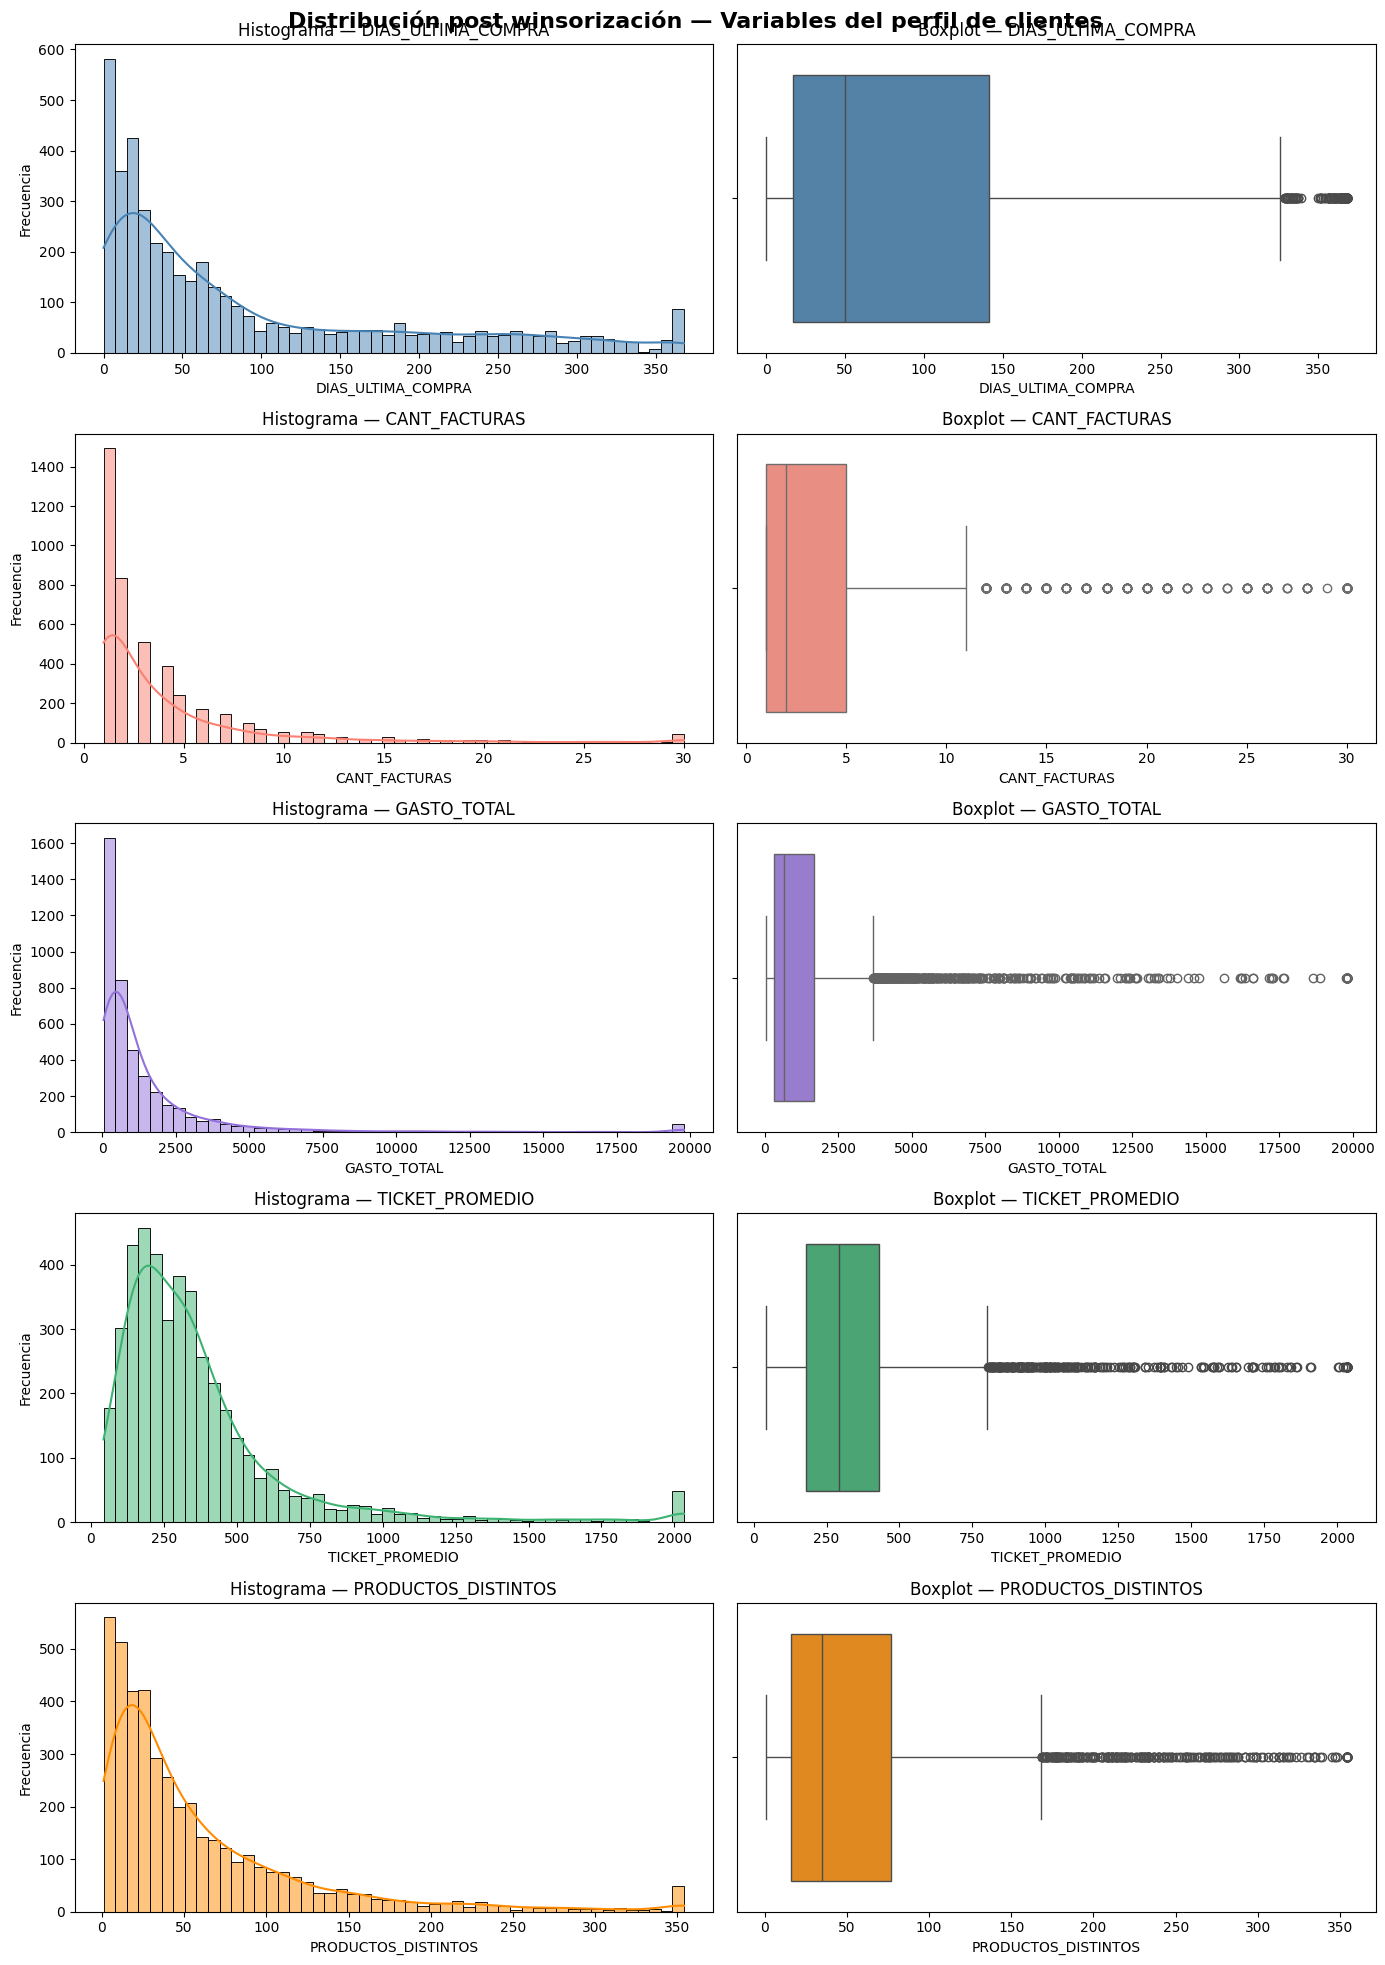

In [31]:
fig, axes = plt.subplots(5, 2, figsize=(14, 20))
fig.suptitle('Distribución post winsorización — Variables del perfil de clientes',
             fontsize=16, fontweight='bold')

colors = ['steelblue', 'salmon', 'mediumpurple', 'mediumseagreen', 'darkorange']

for i, (col, color) in enumerate(zip(cols_perfil, colors)):
    sns.histplot(perfil_winsor[col], bins=50, ax=axes[i,0], color=color, kde=True)
    axes[i,0].set_title(f'Histograma — {col}')
    axes[i,0].set_xlabel(col)
    axes[i,0].set_ylabel('Frecuencia')

    sns.boxplot(x=perfil_winsor[col], ax=axes[i,1], color=color)
    axes[i,1].set_title(f'Boxplot — {col}')
    axes[i,1].set_xlabel(col)

plt.tight_layout()
plt.show()

La winsorización recortó los valores del 1% inferior y superior de cada variable, reemplazándolos por los límites de ese percentil. El efecto es visible en todas las variables pero especialmente pronunciado en `GASTO_TOTAL` y `TICKET_PROMEDIO`.

Estas dos variables son las más afectadas porque concentraban los clientes mayoristas identificados anteriormente — aquellos que operan en una escala cualitativamente distinta al cliente típico y que, de no tratarse, arrastrarían los centroides de K-Means hacia sus valores extremos.

###Transformación logarítmica

A pesar de que la winsorización acotó los valores extremos, las distribuciones siguen siendo asimétricas: la mediana de `GASTO_TOTAL` (£668) sigue siendo menos de la mitad de la media (£1.593), y lo mismo ocurre en `CANT_FACTURAS` y `PRODUCTOS_DISTINTOS`. Esto indica que la cola derecha, aunque recortada, sigue siendo lo suficientemente larga como para afectar el comportamiento del modelo.

Esto perjudica a K-Means porque el algoritmo calcula distancias euclidianas: en una distribución sesgada, las diferencias en la cola pesan desproporcionadamente y los centroides se desplazan hacia esa zona, representando mal al grueso de los clientes.

Para corregirlo aplicamos transformación logarítmica sobre las cinco variables. El logaritmo comprime la cola derecha y produce distribuciones más simétricas, lo que permite que K-Means trate las diferencias entre clientes de forma más equilibrada.


Estadísticas después de transformación logarítmica:
       DIAS_ULTIMA_COMPRA  CANT_FACTURAS  GASTO_TOTAL  TICKET_PROMEDIO  \
count             4338.00        4338.00      4338.00          4338.00   
mean                 3.77           1.34         6.58             5.65   
std                  1.43           0.66         1.21             0.70   
min                  0.00           0.69         3.97             3.79   
25%                  2.89           0.69         5.73             5.19   
50%                  3.93           1.10         6.51             5.68   
75%                  4.96           1.79         7.42             6.06   
max                  5.91           3.43         9.89             7.62   

       PRODUCTOS_DISTINTOS  
count              4338.00  
mean                  3.55  
std                   1.12  
min                   0.69  
25%                   2.83  
50%                   3.58  
75%                   4.36  
max                   5.87  


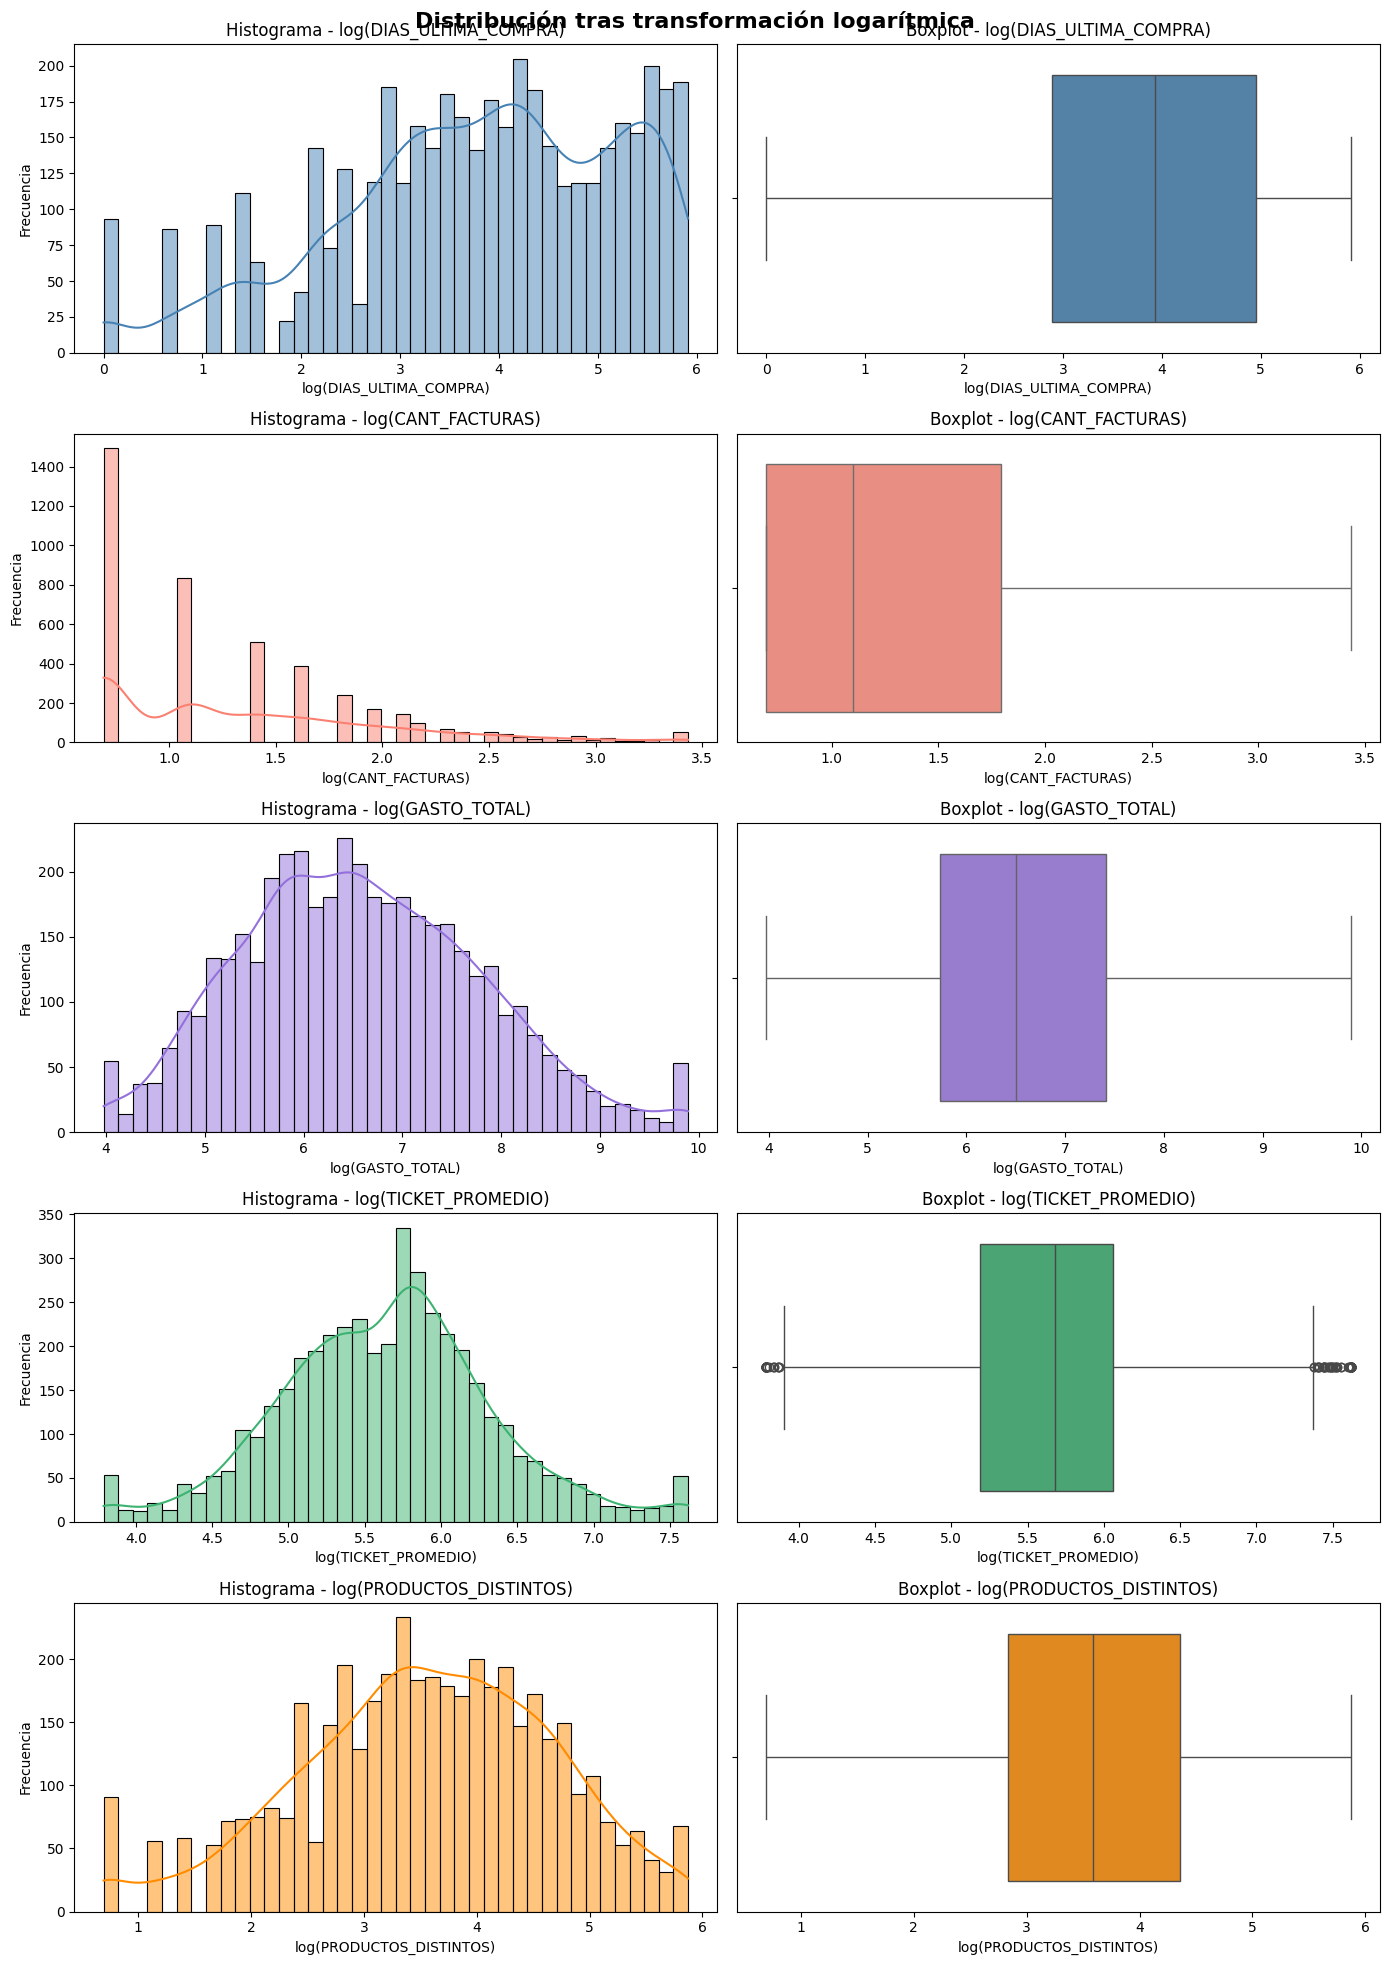

In [32]:
# Transformación logarítmica sobre el perfil winsorizado
perfil_log = perfil_winsor.copy()

for col in cols_perfil:
    perfil_log[col] = np.log1p(perfil_winsor[col])

print("Estadísticas después de transformación logarítmica:")
print(perfil_log[cols_perfil].describe().round(2))

# Visualización post log
fig, axes = plt.subplots(5, 2, figsize=(14, 20))
fig.suptitle('Distribución tras transformación logarítmica', fontsize=16, fontweight='bold')

colors = ['steelblue', 'salmon', 'mediumpurple', 'mediumseagreen', 'darkorange']

for i, (col, color) in enumerate(zip(cols_perfil, colors)):
    sns.histplot(perfil_log[col], bins=40, ax=axes[i, 0], color=color, kde=True)
    axes[i, 0].set_title(f'Histograma - log({col})')
    axes[i, 0].set_xlabel(f'log({col})')
    axes[i, 0].set_ylabel('Frecuencia')

    sns.boxplot(x=perfil_log[col], ax=axes[i, 1], color=color)
    axes[i, 1].set_title(f'Boxplot - log({col})')
    axes[i, 1].set_xlabel(f'log({col})')

plt.tight_layout()
plt.show()

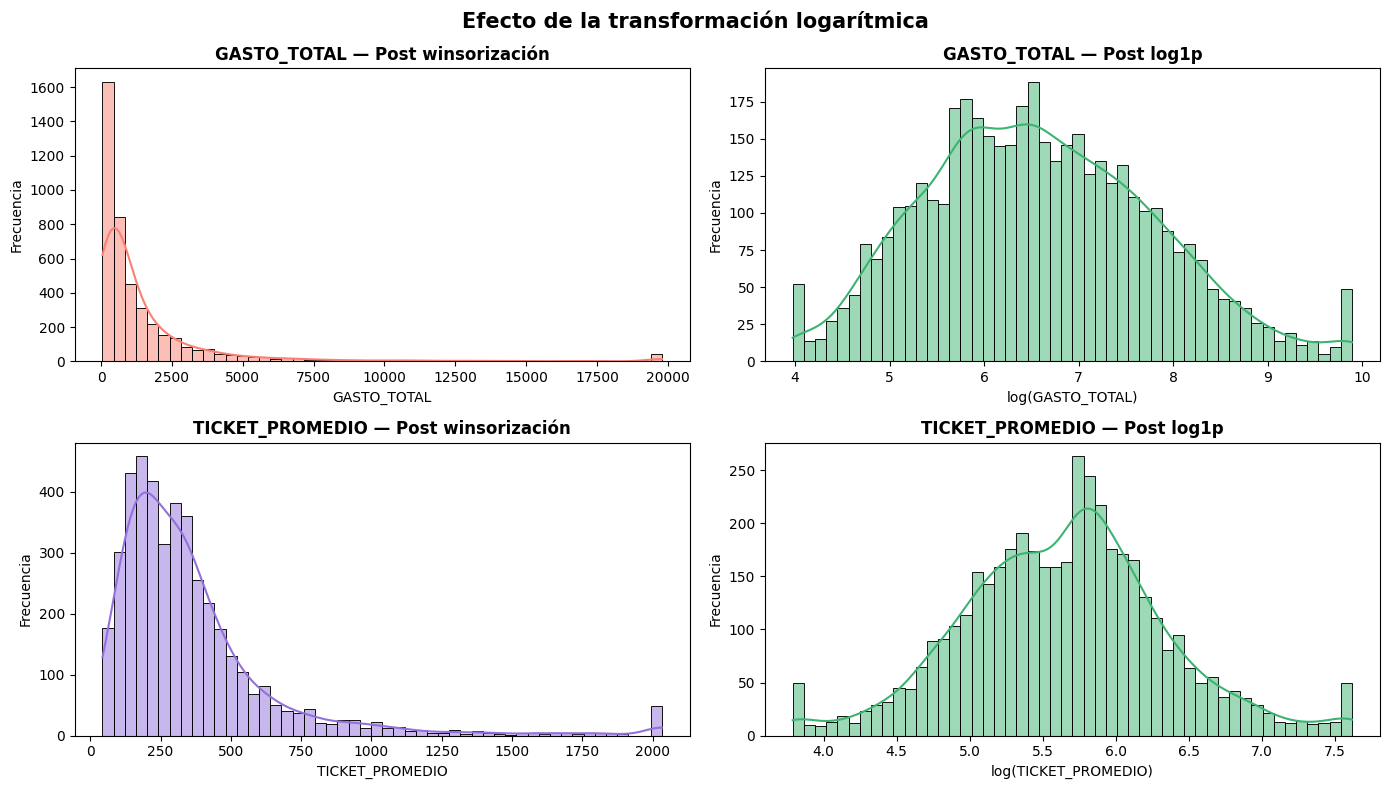

In [33]:
# Comparación antes y después de la transformación logarítmica
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('Efecto de la transformación logarítmica',
             fontsize=15, fontweight='bold')

variables_comparar = ['GASTO_TOTAL', 'TICKET_PROMEDIO']
colors = ['salmon', 'mediumpurple']

for i, (col, color) in enumerate(zip(variables_comparar, colors)):
    # Antes
    sns.histplot(perfil_winsor[col], bins=50, ax=axes[i,0], color=color, kde=True)
    axes[i,0].set_title(f'{col} — Post winsorización', fontweight='bold')
    axes[i,0].set_xlabel(col)
    axes[i,0].set_ylabel('Frecuencia')

    # Después
    sns.histplot(perfil_log[col], bins=50, ax=axes[i,1], color='mediumseagreen', kde=True)
    axes[i,1].set_title(f'{col} — Post log1p', fontweight='bold')
    axes[i,1].set_xlabel(f'log({col})')
    axes[i,1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

###Escalado: RobustScaler



Aunque la transformación logarítmica redujo el sesgo de las distribuciones, las cinco variables siguen teniendo escalas distintas entre sí. K-Means calcula distancias euclidianas entre puntos, por lo que una variable con mayor escala domina automáticamente el cálculo aunque no sea la más importante para definir los segmentos.

Para corregir esto estandarizamos las variables antes de entrenar el modelo.

Optamos por **RobustScaler** en lugar de StandardScaler porque, si bien la winsorización y el logaritmo redujeron el impacto de los outliers, pueden existir valores residuales que afecten la media y el desvío estándar que utiliza StandardScaler.

RobustScaler escala usando la mediana y el rango intercuartílico (IQR), métricas que no se ven afectadas por esos valores extremos, lo que lo hace más apropiado para este dataset.

Aplicamos el escalado sobre las cinco variables del perfil: `DIAS_ULTIMA_COMPRA`, `CANT_FACTURAS`, `GASTO_TOTAL`, `TICKET_PROMEDIO` y `PRODUCTOS_DISTINTOS`.

In [34]:
scaler = RobustScaler()

perfil_scaled = scaler.fit_transform(perfil_log[cols_perfil])
perfil_scaled = pd.DataFrame(perfil_scaled, columns=cols_perfil, index=perfil_log.index)

print("Estadísticas después de RobustScaler:")
print(perfil_scaled.describe().round(2))

Estadísticas después de RobustScaler:
       DIAS_ULTIMA_COMPRA  CANT_FACTURAS  GASTO_TOTAL  TICKET_PROMEDIO  \
count             4338.00        4338.00      4338.00          4338.00   
mean                -0.08           0.22         0.05            -0.04   
std                  0.69           0.61         0.72             0.80   
min                 -1.90          -0.37        -1.50            -2.16   
25%                 -0.50          -0.37        -0.46            -0.56   
50%                  0.00           0.00        -0.00             0.00   
75%                  0.50           0.63         0.54             0.44   
max                  0.96           2.13         2.01             2.21   

       PRODUCTOS_DISTINTOS  
count              4338.00  
mean                 -0.02  
std                   0.74  
min                  -1.90  
25%                  -0.49  
50%                   0.00  
75%                   0.51  
max                   1.50  


###Visualización perfil_scaled

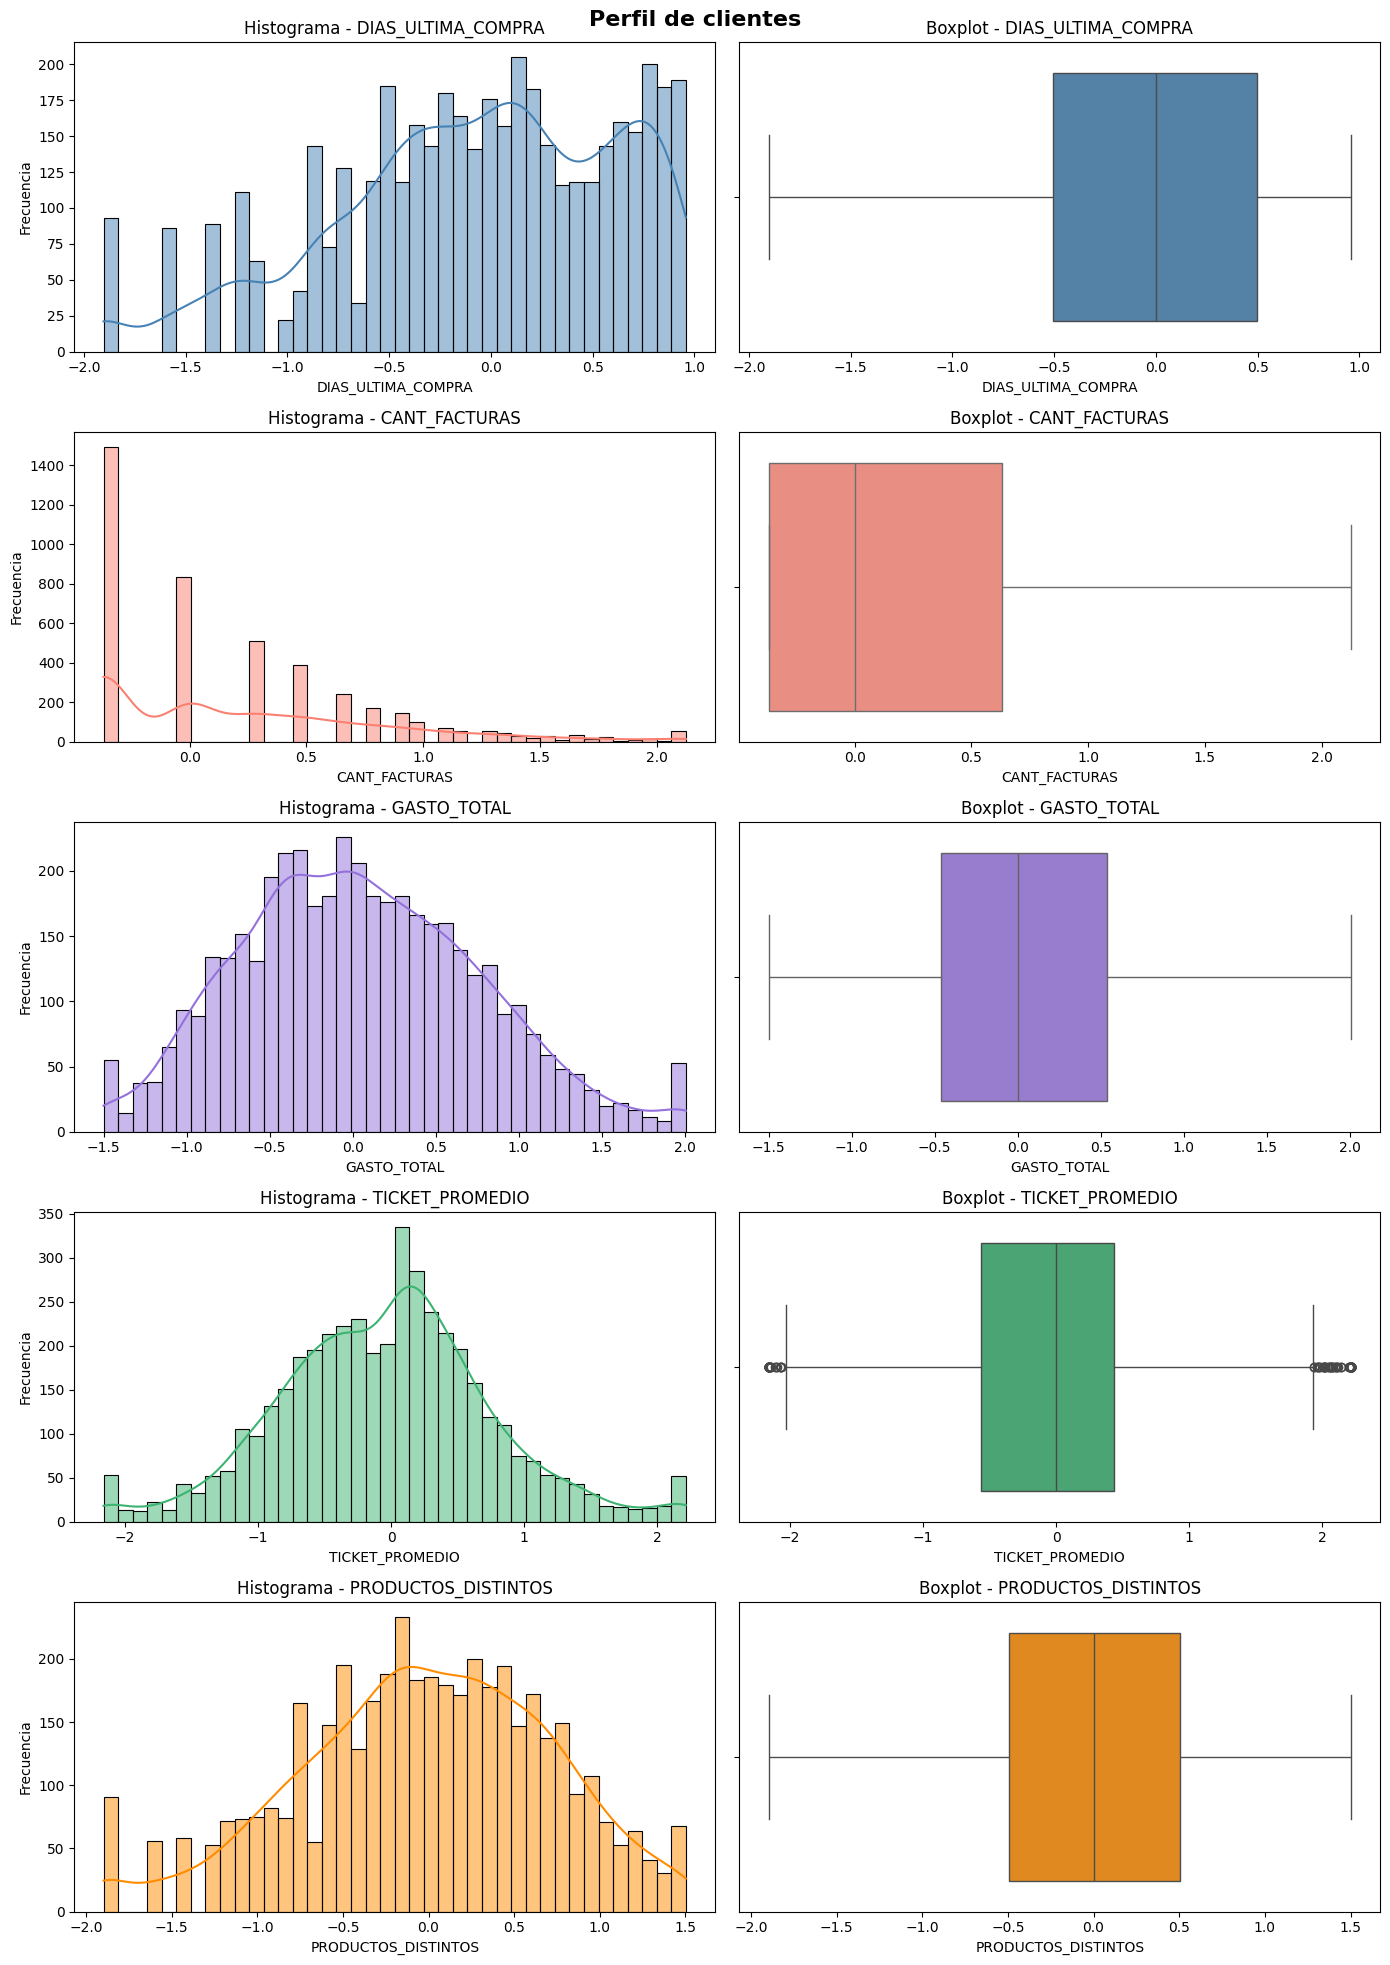

In [35]:
fig, axes = plt.subplots(5, 2, figsize=(14, 20))
fig.suptitle('Perfil de clientes', fontsize=16, fontweight='bold')

colors = ['steelblue', 'salmon', 'mediumpurple', 'mediumseagreen', 'darkorange']

for i, (col, color) in enumerate(zip(cols_perfil, colors)):
    sns.histplot(perfil_scaled[col], bins=40, ax=axes[i, 0], color=color, kde=True)
    axes[i, 0].set_title(f'Histograma - {col}')
    axes[i, 0].set_xlabel(col)
    axes[i, 0].set_ylabel('Frecuencia')

    sns.boxplot(x=perfil_scaled[col], ax=axes[i, 1], color=color)
    axes[i, 1].set_title(f'Boxplot - {col}')
    axes[i, 1].set_xlabel(col)

plt.tight_layout()
plt.show()

El dataset de entrada para los modelos de clustering es `perfil_scaled`, que contiene **4.338 clientes** con las siguientes variables transformadas y escaladas:

| Variable | Transformación aplicada |
|---|---|
| `DIAS_ULTIMA_COMPRA` | Winsorización + log1p + RobustScaler |
| `CANT_FACTURAS` | Winsorización + log1p + RobustScaler |
| `GASTO_TOTAL` | Winsorización + log1p + RobustScaler |
| `TICKET_PROMEDIO` | Winsorización + log1p + RobustScaler |
| `PRODUCTOS_DISTINTOS` | Winsorización + log1p + RobustScaler |

Las primeras tres variables conforman el enfoque **RFM** (Recency, Frequency, Monetary), un estándar en análisis de clientes de e-commerce. Las dos variables adicionales enriquecen el perfil capturando dimensiones que RFM no cubre: cuánto gasta el cliente por visita y qué tan variado es su comportamiento de compra.

`retail_cured` cumplió su función: limpiar las transacciones para construir el perfil
correctamente. De acá en adelante el dataset con el que trabaja el modelo es `perfil_scaled`.

#Aplicación de modelos

### Modelo K-Means

#### Elección del número de clusters (K)

Antes de entrenar el modelo necesitamos definir el parámetro de cuántos clusters usar. Para eso aplicamos dos métodos complementarios:

- **Método del codo**: graficamos la inercia (suma de distancias cuadradas de cada
punto a su centroide) para distintos valores de K. Buscamos el punto donde la curva
deja de bajar bruscamente, que indica el K a partir del cual agregar más clusters
no mejora significativamente el modelo.

- **Coeficiente de silueta**: mide qué tan bien está asignado cada cliente a su
cluster. Valores cercanos a 1 indican clusters bien definidos, valores cercanos a
0 indican superposición entre clusters.

Nosotros consideramos que la combinación de ambos métodos nos da una decisión más
sólida que usar cualquiera de los dos por separado.

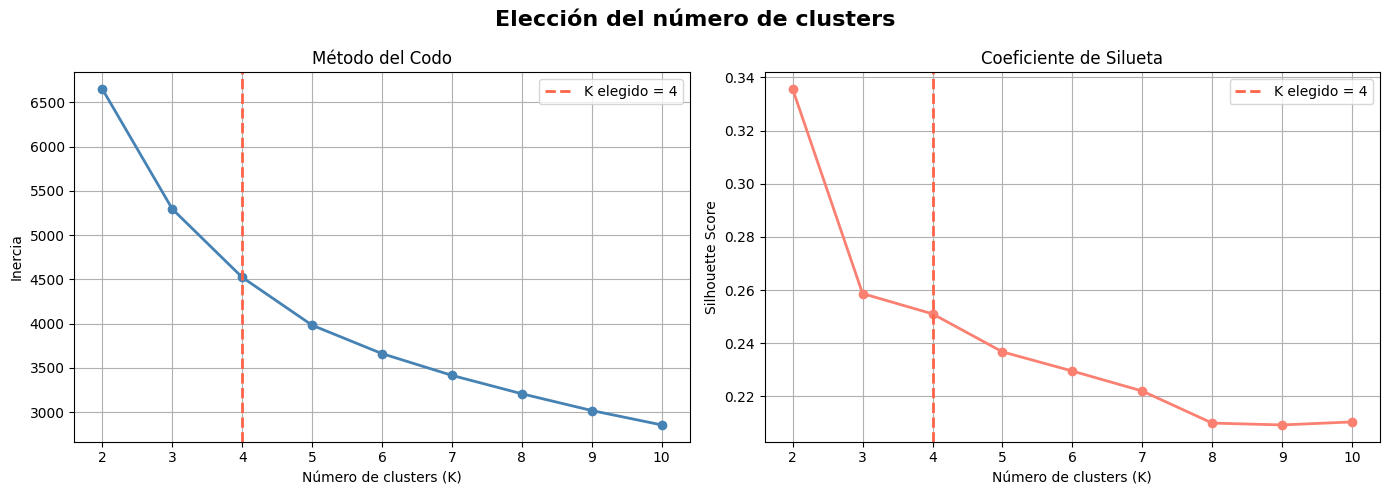


Resumen:
K=2  |  Inercia: 6648.28  |  Silueta: 0.3356
K=3  |  Inercia: 5294.58  |  Silueta: 0.2587
K=4  |  Inercia: 4522.88  |  Silueta: 0.2511
K=5  |  Inercia: 3982.12  |  Silueta: 0.2368
K=6  |  Inercia: 3661.26  |  Silueta: 0.2295
K=7  |  Inercia: 3415.81  |  Silueta: 0.2220
K=8  |  Inercia: 3207.92  |  Silueta: 0.2099
K=9  |  Inercia: 3018.69  |  Silueta: 0.2093
K=10  |  Inercia: 2856.17  |  Silueta: 0.2104


In [36]:
inercias = []
siluetas = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(perfil_scaled)
    inercias.append(kmeans.inertia_)
    siluetas.append(silhouette_score(perfil_scaled, kmeans.labels_))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Elección del número de clusters', fontsize=16, fontweight='bold')

axes[0].plot(K_range, inercias, marker='o', color='steelblue', linewidth=2)
axes[0].set_title('Método del Codo')
axes[0].set_xlabel('Número de clusters (K)')
axes[0].set_ylabel('Inercia')
axes[0].grid(True)
axes[0].axvline(x=4, color='tomato', linestyle='--', linewidth=2, label='K elegido = 4')
axes[0].legend()

axes[1].plot(K_range, siluetas, marker='o', color='salmon', linewidth=2)
axes[1].set_title('Coeficiente de Silueta')
axes[1].set_xlabel('Número de clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].grid(True)
axes[1].axvline(x=4, color='tomato', linestyle='--', linewidth=2, label='K elegido = 4')
axes[1].legend()

plt.tight_layout()
plt.show()

print("\nResumen:")
for k, inercia, silueta in zip(K_range, inercias, siluetas):
    print(f"K={k}  |  Inercia: {inercia:.2f}  |  Silueta: {silueta:.4f}")

**Elección de K=4**

El método del codo muestra que la inercia cae bruscamente hasta K=4 y luego se
estabiliza, lo que indica que agregar más clusters a partir de ese punto no aporta una mejora significativa en la compacidad de los grupos.

Si bien el coeficiente de silueta es más alto en K=2 (0.33), dos segmentos resultan insuficientes para capturar la diversidad de comportamientos de compra que existe en la base de clientes.

K=4 ofrece un balance adecuado entre calidad del clustering
(silueta: 0.25) y utilidad para el negocio, generando segmentos lo suficientemente
distintos como para diseñar estrategias de marketing diferenciadas.

####Entrenamiento con K = 4

In [37]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
kmeans.fit(perfil_scaled)

# Agregamos etiquetas SOLO a perfil_clientes, perfil_scaled queda limpio
perfil_clientes['CLUSTER'] = kmeans.labels_
perfil_clientes['NOMBRE_CLUSTER'] = perfil_clientes['CLUSTER'].map({
    0: 'Premium',
    1: 'Perdidos',
    2: 'Ocasionales de Alto Ticket',
    3: 'Por Desarrollar'
})

print(f"Inercia final: {kmeans.inertia_:.2f}")
print(f"Silueta final: {silhouette_score(perfil_scaled, kmeans.labels_):.4f}")
print()
print("Distribución de clientes por cluster:")
print(perfil_clientes['CLUSTER'].value_counts().sort_index())

Inercia final: 4522.88
Silueta final: 0.2511

Distribución de clientes por cluster:
CLUSTER
0     984
1    1047
2    1187
3    1120
Name: count, dtype: int64


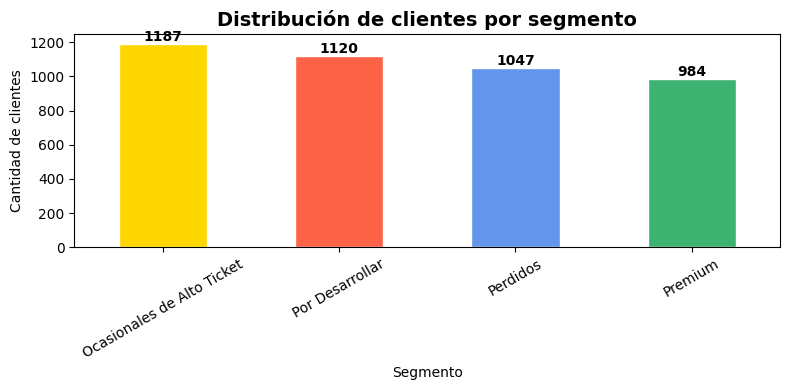

In [38]:
fig, ax = plt.subplots(figsize=(8, 4))
counts = perfil_clientes['NOMBRE_CLUSTER'].value_counts()
colors_seg = ['gold', 'tomato', 'cornflowerblue', 'mediumseagreen']
counts.plot(kind='bar', ax=ax, color=colors_seg, edgecolor='white')
ax.set_title('Distribución de clientes por segmento', fontsize=14, fontweight='bold')
ax.set_xlabel('Segmento')
ax.set_ylabel('Cantidad de clientes')
ax.tick_params(axis='x', rotation=30)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.show()

####Interpretacion clusters

In [39]:
# Interpretación de los clusters con valores reales
interpretacion = perfil_clientes.groupby('CLUSTER')[cols_perfil].mean().round(2)
print(interpretacion)

         DIAS_ULTIMA_COMPRA  CANT_FACTURAS  GASTO_TOTAL  TICKET_PROMEDIO  \
CLUSTER                                                                    
0                     22.52          11.06      6667.32           652.88   
1                    158.15           1.47       198.62           143.94   
2                    142.59           1.66      1013.67           635.19   
3                     35.80           3.70       817.31           236.29   

         PRODUCTOS_DISTINTOS  
CLUSTER                       
0                     150.18  
1                      12.72  
2                      35.54  
3                      56.71  


Observamos los siguientes clusters con sus caracteristicas.


**Cluster 0 — Clientes Premium**: alta frecuencia, gasto elevado, compra reciente. Los más valiosos de la base.

**Cluster 1 — Clientes Perdidos**: inactivos hace más de 5 meses, baja frecuencia y gasto mínimo.

**Cluster 2 — Ocasionales de Alto Ticket**: inactivos pero con ticket promedio alto cuando compraron.

**Cluster 3 — Por Desarrollar**: activos y con frecuencia media, potencial de crecimiento.

In [40]:
fig = px.scatter_3d(
    perfil_scaled,
    x='DIAS_ULTIMA_COMPRA',
    y='CANT_FACTURAS',
    z='GASTO_TOTAL',
    color=perfil_clientes['NOMBRE_CLUSTER'],
    color_discrete_map={
        'Premium': 'mediumseagreen',
        'Perdidos': 'cornflowerblue',
        'Ocasionales de Alto Ticket': 'gold',
        'Por Desarrollar': 'tomato'
    },
    custom_data=[
        perfil_clientes['DIAS_ULTIMA_COMPRA'],
        perfil_clientes['CANT_FACTURAS'],
        perfil_clientes['GASTO_TOTAL'],
        perfil_clientes['TICKET_PROMEDIO'],
        perfil_clientes['PRODUCTOS_DISTINTOS']
    ],
    title='Segmentación de clientes K-Means - K=4',
    labels={
        'DIAS_ULTIMA_COMPRA': 'Recencia (escalada)',
        'CANT_FACTURAS': 'Frecuencia (escalada)',
        'GASTO_TOTAL': 'Monto (escalado)',
        'color': 'Segmento'
    },
    opacity=0.7
)

fig.update_traces(
    marker=dict(size=3),
    hovertemplate=(
        '<b>Recencia real:</b> %{customdata[0]:.0f} días<br>'
        '<b>Frecuencia real:</b> %{customdata[1]:.0f} facturas<br>'
        '<b>Gasto real:</b> £%{customdata[2]:.2f}<br>'
        '<b>Ticket promedio:</b> £%{customdata[3]:.2f}<br>'
        '<b>Productos distintos:</b> %{customdata[4]:.0f}<br>'
    )
)

fig.update_layout(legend_title_text='Segmento')
fig.show()

##Modelo DBSCAN

A diferencia de K-Means, **DBSCAN** (Density-Based Spatial Clustering of Applications with Noise) es un algoritmo de clustering basado en densidad que no requiere definir el número de clusters de antemano. En cambio, agrupa los puntos que están densamente conectados entre sí y marca como ruido los puntos aislados que no pertenecen a ningún grupo.

El algoritmo trabaja con dos parámetros:

- **eps**: radio máximo de vecindad. Define qué tan cerca tienen que estar dos puntos para considerarse vecinos.
- **min_samples**: cantidad mínima de puntos dentro del radio `eps` para que una región se considere densa y forme un cluster.

Nosotros consideramos que vale la pena probarlo como alternativa a K-Means por tres razones:

- No asume que los clusters tienen forma esférica como K-Means
- Detecta automáticamente el número de clusters
- Identifica y separa explícitamente los clientes atípicos como ruido,
en lugar de forzarlos dentro de algún segmento

La principal limitación es que encontrar los valores correctos de `eps` y `min_samples` requiere experimentación. Por eso probamos distintas combinaciones y evaluamos los resultados con el coeficiente de silueta antes de elegir los parámetros finales.

### Elección de parámetros para DBSCAN

In [41]:
# perfil_scaled está limpio: no tiene columnas de K-Means
resultados = []

for eps in np.arange(0.2, 1, 0.05):
    for min_samples in [2, 3, 5, 7, 10]:
        db = DBSCAN(eps=eps, min_samples=min_samples)
        labels = db.fit_predict(perfil_scaled)

        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_ruido    = (labels == -1).sum()

        if n_clusters > 1 and n_ruido < len(labels) * 0.5:
            sil = silhouette_score(perfil_scaled, labels)
        else:
            sil = None

        resultados.append({
            'eps':         round(eps, 2),
            'min_samples': min_samples,
            'n_clusters':  n_clusters,
            'n_ruido':     n_ruido,
            'pct_ruido':   round(n_ruido / len(labels) * 100, 1),
            'silueta':     round(sil, 4) if sil else None
        })

resultados_df = pd.DataFrame(resultados)
resultados_top10 = (
    resultados_df
    .dropna(subset=['silueta'])
    .query('silueta >= 0')
    .sort_values('silueta', ascending=False)
    .head(20)
)

print("Top 10 combinaciones de parámetros:")
print(resultados_top10.to_string(index=False))

Top 10 combinaciones de parámetros:
 eps  min_samples  n_clusters  n_ruido  pct_ruido  silueta
0.75           10           2       45        1.0   0.3643
0.75            7           2       24        0.6   0.3569
0.95            2           2        4        0.1   0.3558
0.95            3           2        4        0.1   0.3558
0.80            3           2        8        0.2   0.3543
0.85            3           2        8        0.2   0.3543
0.70            7           2       42        1.0   0.3528
0.70            5           2       30        0.7   0.3419
0.65            5           2       53        1.2   0.3417
0.70            3           2       23        0.5   0.3403
0.90            3           2        5        0.1   0.3349
0.90            2           2        5        0.1   0.3349
0.65            3           3       27        0.6   0.3347
0.75            3           3       12        0.3   0.3334
0.60            5           2       88        2.0   0.3265
0.85            2   

Tras probar distintas combinaciones evaluamos cada resultado por tres criterios: número de clusters razonable para segmentación de marketing, coeficiente de silueta alto y porcentaje de ruido bajo.

A diferencia de lo que esperábamos, DBSCAN no encontró naturalmente 4 clusters
como K-Means. Las combinaciones que generaban 4 grupos terminaban con un solo
cluster real y el resto como ruido, lo que no tiene utilidad para el negocio.

Elegimos `eps=0.7` y `min_samples=5` porque es la combinación que mejor equilibra los tres criterios: detecta 2 clusters bien definidos, obtiene la silueta más alta y clasifica como ruido apenas 30 clientes (0.7% del total).

Este resultado es en sí mismo una conclusión importante: **la estructura natural de los datos, según DBSCAN, es de dos grandes grupos**. Esto contrasta con los 4 segmentos que K-Means encontró al ser forzado a dividir el espacio en 4 partes.
Ninguno de los dos está equivocado, simplemente responden preguntas distintas:

- **K-Means** pregunta: *¿cómo divido mejor estos clientes en 4 grupos?*
- **DBSCAN** pregunta: *¿qué estructura existe naturalmente en los datos?*

La respuesta de DBSCAN sugiere que hay una división fundamental entre clientes
activos y clientes inactivos.

### Entrenamiento de DBSCAN con parámetros elegidos

In [42]:
db = DBSCAN(eps=0.7, min_samples=5)
labels = db.fit_predict(perfil_scaled)

# Agregamos etiquetas SOLO a perfil_clientes
perfil_clientes['CLUSTER_DBSCAN'] = labels
perfil_clientes['NOMBRE_CLUSTER_DBSCAN'] = perfil_clientes['CLUSTER_DBSCAN'].map({
    -1: 'Atípicos',
    0:  'Clientes Estandar',
    1:  'Mega Mayoristas'
})

n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_ruido    = (labels == -1).sum()

print(f"Clusters detectados: {n_clusters}")
print(f"Puntos de ruido:     {n_ruido} ({n_ruido/len(labels)*100:.1f}%)")
print(f"Silueta:             {silhouette_score(perfil_scaled, labels):.4f}")
print()
print("Distribución de clientes por cluster:")
print(perfil_clientes['CLUSTER_DBSCAN'].value_counts().sort_index())

Clusters detectados: 2
Puntos de ruido:     30 (0.7%)
Silueta:             0.3419

Distribución de clientes por cluster:
CLUSTER_DBSCAN
-1      30
 0    4297
 1      11
Name: count, dtype: int64


In [43]:
print("Cluster 0 - características:")
print(perfil_clientes[perfil_clientes['CLUSTER_DBSCAN'] == 0][cols_perfil].describe().round(2))

print("\nCluster 1 - características:")
print(perfil_clientes[perfil_clientes['CLUSTER_DBSCAN'] == 1][cols_perfil].describe().round(2))

print("\nRuido - características:")
print(perfil_clientes[perfil_clientes['CLUSTER_DBSCAN'] == -1][cols_perfil].describe().round(2))

Cluster 0 - características:
       DIAS_ULTIMA_COMPRA  CANT_FACTURAS  GASTO_TOTAL  TICKET_PROMEDIO  \
count             4297.00        4297.00      4297.00          4297.00   
mean                91.96           4.14      1608.38           360.89   
std                 99.98           7.36      4030.55           346.90   
min                  0.00           1.00         3.75             3.45   
25%                 17.00           1.00       305.54           177.56   
50%                 50.00           2.00       660.00           290.25   
75%                142.00           5.00      1621.88           423.72   
max                373.00         209.00    143711.17          6207.67   

       PRODUCTOS_DISTINTOS  
count              4297.00  
mean                 60.48  
std                  80.96  
min                   1.00  
25%                  16.00  
50%                  35.00  
75%                  77.00  
max                1787.00  

Cluster 1 - características:
       DIAS_U

### Interpretación de los clusters DBSCAN

DBSCAN no encontró la misma estructura de 4 grupos que K-Means. En cambio,
identificó una división más fundamental en los datos:

**Cluster 0 — Clientes Estándar (4.297 clientes)**
El grueso de la base de clientes. Gasto medio de £1.608, frecuencia promedio
de 4 facturas y 60 productos distintos. Dentro de este grupo conviven tanto
clientes activos como inactivos, pero su comportamiento de compra es comparable
en magnitud.

**Cluster 1 — Mega Mayoristas (11 clientes)**
Un grupo pequeño pero extraordinario: gasto medio de £120.727, 38 facturas
promedio y 530 productos distintos. Son compradores de escala completamente
diferente al resto de la base. K-Means los había absorbido dentro del segmento
Premium, pero DBSCAN los reconoce como una categoría propia.

**Ruido (-1) — Clientes Atípicos (30 clientes)**
Casos con comportamiento inconsistente: ticket promedio muy alto (£7.493)
pero baja frecuencia. No encajan en ningún patrón claro.

---

Esta división revela algo que K-Means no capturó: **existe una diferencia
cualitativa entre los clientes comunes y un pequeño grupo de mega mayoristas**
que operan en una escala completamente distinta. Para el equipo de marketing
esto implica que esos 11 clientes merecen una estrategia de cuenta clave
completamente separada del resto.

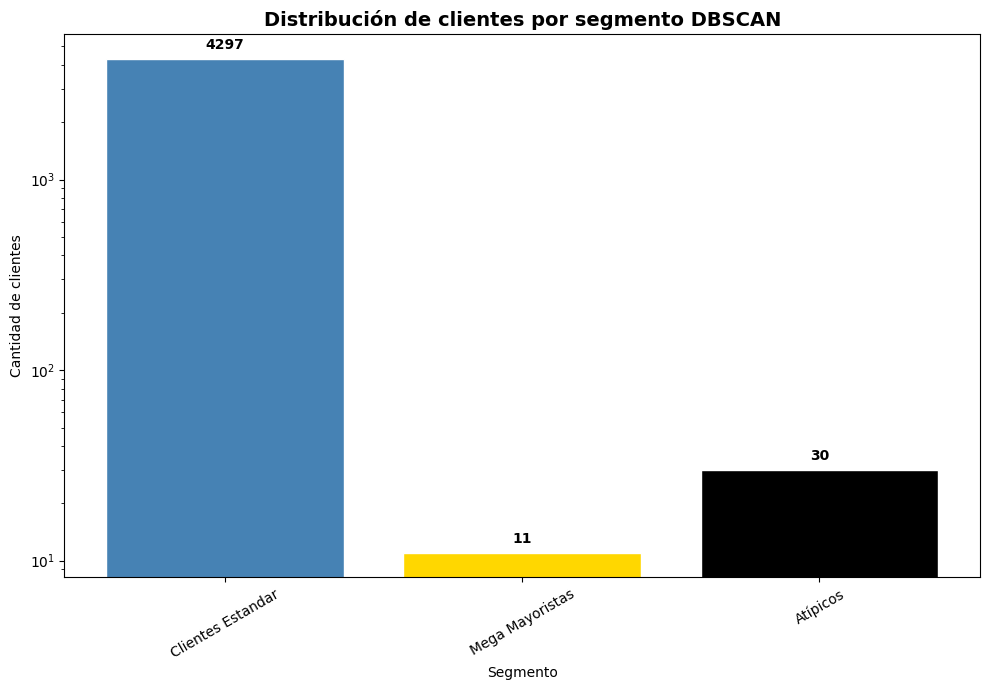

In [44]:
fig, ax = plt.subplots(figsize=(10, 7)) # Increased height
counts_dbscan = perfil_clientes['NOMBRE_CLUSTER_DBSCAN'].value_counts().sort_index()

colores_dbscan = {
    'Clientes Estandar': 'steelblue',
    'Mega Mayoristas': 'gold',
    'Atípicos': 'black'
}

# Ensure the order of bars matches the specified colors
ordered_labels = ['Clientes Estandar', 'Mega Mayoristas', 'Atípicos']
counts_dbscan = counts_dbscan.reindex(ordered_labels)

bars = ax.bar(counts_dbscan.index, counts_dbscan.values,
              color=[colores_dbscan[label] for label in counts_dbscan.index],
              edgecolor='white')

ax.set_title('Distribución de clientes por segmento DBSCAN', fontsize=14, fontweight='bold')
ax.set_xlabel('Segmento')
ax.set_ylabel('Cantidad de clientes')
ax.set_yscale('log') # Apply logarithmic scale
ax.tick_params(axis='x', rotation=30)

for p in bars:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom',  # Keep bottom alignment
                xytext=(0, 5),             # Add a small vertical offset (5 points)
                textcoords='offset points',
                fontweight='bold')

plt.tight_layout()
plt.show()

In [45]:
fig = px.scatter_3d(
    perfil_scaled,
    x='DIAS_ULTIMA_COMPRA',
    y='CANT_FACTURAS',
    z='GASTO_TOTAL',
    color=perfil_clientes['NOMBRE_CLUSTER_DBSCAN'],
    color_discrete_map={
        'Clientes Activos': 'steelblue',
        'Mega Mayoristas': 'gold',
        'Atípicos': 'black'
    },
    custom_data=[
        perfil_clientes['DIAS_ULTIMA_COMPRA'],
        perfil_clientes['CANT_FACTURAS'],
        perfil_clientes['GASTO_TOTAL'],
        perfil_clientes['TICKET_PROMEDIO'],
        perfil_clientes['PRODUCTOS_DISTINTOS']
    ],
    title='Segmentación de clientes DBSCAN - eps=0.7',
    labels={
        'DIAS_ULTIMA_COMPRA': 'Recencia (escalada)',
        'CANT_FACTURAS': 'Frecuencia (escalada)',
        'GASTO_TOTAL': 'Monto (escalado)',
        'color': 'Segmento'
    },
    opacity=0.7
)

fig.update_traces(
    marker=dict(size=3),
    hovertemplate=(
        '<b>Recencia real:</b> %{customdata[0]:.0f} días<br>'
        '<b>Frecuencia real:</b> %{customdata[1]:.0f} facturas<br>'
        '<b>Gasto real:</b> £%{customdata[2]:.2f}<br>'
        '<b>Ticket promedio:</b> £%{customdata[3]:.2f}<br>'
        '<b>Productos distintos:</b> %{customdata[4]:.0f}<br>'
    )
)

fig.update_layout(legend_title_text='Segmento')
fig.show()

##K-Means vs. DBSCAN

###Resultados K-Means

Se entrenó el modelo con K = 4, seleccionado a partir del método del codo y el coeficiente de silueta. La distribución resultante es equilibrada: 984, 1.047, 1.187 y 1.120 clientes por segmento, lo que indica que el modelo encontró
grupos reales y no triviales.

El coeficiente de silueta final fue de 0.2511.

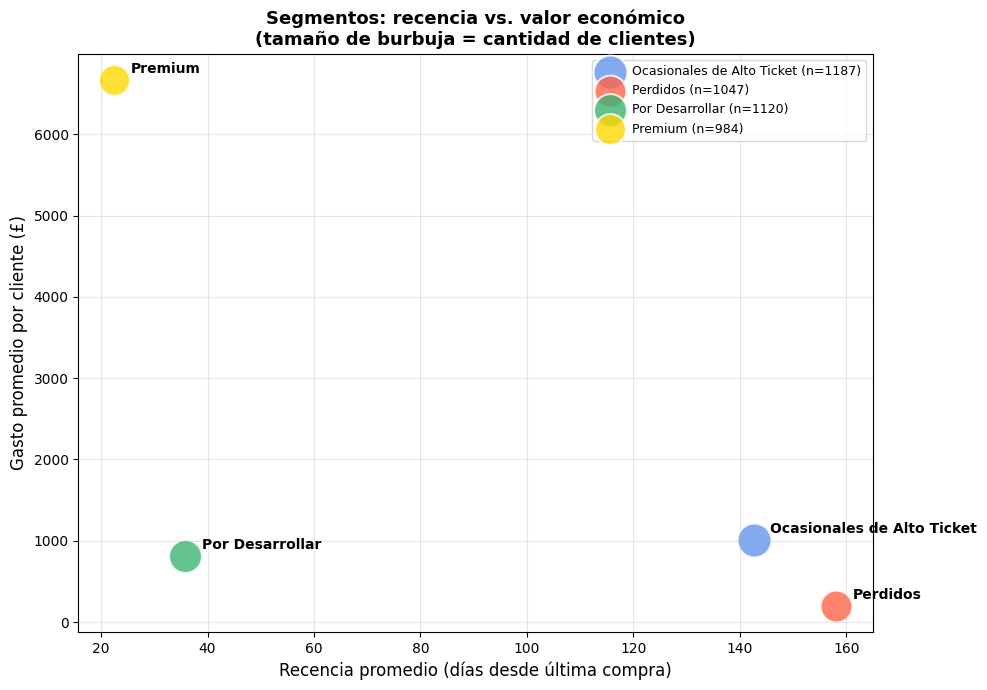


Valor económico por segmento:
                            n_clientes  gasto_total  gasto_promedio
NOMBRE_CLUSTER                                                     
Ocasionales de Alto Ticket        1187   1203221.54         1013.67
Perdidos                          1047    207958.95          198.62
Por Desarrollar                   1120    915383.13          817.31
Premium                            984   6560645.27         6667.32


In [46]:
# Datos por segmento
resumen = perfil_clientes.groupby('NOMBRE_CLUSTER').agg(
    n_clientes    = ('CLUSTER', 'count'),
    gasto_total   = ('GASTO_TOTAL', 'sum'),
    gasto_promedio= ('GASTO_TOTAL', 'mean'),
    recencia_media= ('DIAS_ULTIMA_COMPRA', 'mean'),
    frecuencia_media=('CANT_FACTURAS', 'mean')
).round(2)

colores = {
    'Premium':                  'gold',
    'Perdidos':                 'tomato',
    'Ocasionales de Alto Ticket':'cornflowerblue',
    'Por Desarrollar':          'mediumseagreen'
}

fig, ax = plt.subplots(figsize=(10, 7))

for segmento, row in resumen.iterrows():
    ax.scatter(
        row['recencia_media'],
        row['gasto_promedio'],
        s=row['n_clientes'] * 0.5,      # tamaño de burbuja = cantidad de clientes
        color=colores[segmento],
        alpha=0.8,
        edgecolors='white',
        linewidth=1.5,
        label=f"{segmento} (n={int(row['n_clientes'])})"
    )
    ax.annotate(
        segmento,
        (row['recencia_media'], row['gasto_promedio']),
        textcoords='offset points',
        xytext=(12, 5),
        fontsize=10,
        fontweight='bold'
    )

ax.set_xlabel('Recencia promedio (días desde última compra)', fontsize=12)
ax.set_ylabel('Gasto promedio por cliente (£)', fontsize=12)
ax.set_title('Segmentos: recencia vs. valor económico\n(tamaño de burbuja = cantidad de clientes)',
             fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(loc='upper right', fontsize=9)

plt.tight_layout()
plt.show()

# Tabla de valor económico por segmento
print("\nValor económico por segmento:")
print(resumen[['n_clientes','gasto_total','gasto_promedio']].to_string())

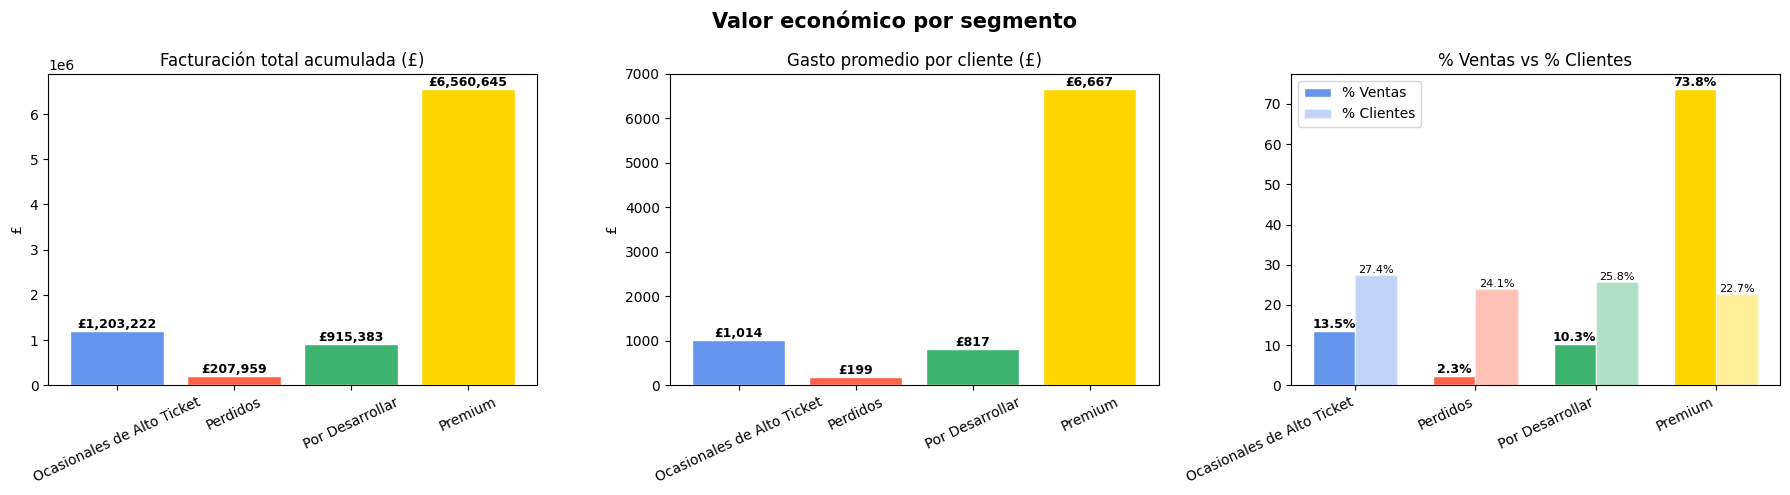

,n_clientes,pct_clientes,gasto_total,pct_ventas,gasto_promedio
NOMBRE_CLUSTER,,,,,
Ocasionales de Alto Ticket,1187,27.4,1203222.0,13.5,1014.0
Perdidos,1047,24.1,207959.0,2.3,199.0
Por Desarrollar,1120,25.8,915383.0,10.3,817.0
Premium,984,22.7,6560645.0,73.8,6667.0


In [47]:
# Facturación total por segmento con % de ventas
resumen_eco = perfil_clientes.groupby('NOMBRE_CLUSTER').agg(
    n_clientes     = ('CLUSTER', 'count'),
    gasto_total    = ('GASTO_TOTAL', 'sum'),
    gasto_promedio = ('GASTO_TOTAL', 'mean')
).round(0)

resumen_eco['pct_ventas']   = (resumen_eco['gasto_total'] / resumen_eco['gasto_total'].sum() * 100).round(1)
resumen_eco['pct_clientes'] = (resumen_eco['n_clientes'] / resumen_eco['n_clientes'].sum() * 100).round(1)

colores = {
    'Premium': 'gold',
    'Perdidos': 'tomato',
    'Ocasionales de Alto Ticket': 'cornflowerblue',
    'Por Desarrollar': 'mediumseagreen'
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Valor económico por segmento', fontsize=15, fontweight='bold')

# Gasto total
bars = axes[0].bar(resumen_eco.index, resumen_eco['gasto_total'],
                   color=[colores[s] for s in resumen_eco.index], edgecolor='white')
axes[0].set_title('Facturación total acumulada (£)')
axes[0].set_ylabel('£')
axes[0].tick_params(axis='x', rotation=25)
for bar, val in zip(bars, resumen_eco['gasto_total']):
    axes[0].annotate(f'£{val:,.0f}',
                     (bar.get_x() + bar.get_width()/2, bar.get_height()),
                     ha='center', va='bottom', fontweight='bold', fontsize=9)

# Gasto promedio por cliente
bars2 = axes[1].bar(resumen_eco.index, resumen_eco['gasto_promedio'],
                    color=[colores[s] for s in resumen_eco.index], edgecolor='white')
axes[1].set_title('Gasto promedio por cliente (£)')
axes[1].set_ylabel('£')
axes[1].tick_params(axis='x', rotation=25)
for bar, val in zip(bars2, resumen_eco['gasto_promedio']):
    axes[1].annotate(f'£{val:,.0f}',
                     (bar.get_x() + bar.get_width()/2, bar.get_height()),
                     ha='center', va='bottom', fontweight='bold', fontsize=9)

# % Ventas vs % Clientes
x = range(len(resumen_eco))
width = 0.35
bars3 = axes[2].bar([i - width/2 for i in x], resumen_eco['pct_ventas'],
                    width=width, label='% Ventas',
                    color=[colores[s] for s in resumen_eco.index], edgecolor='white')
bars4 = axes[2].bar([i + width/2 for i in x], resumen_eco['pct_clientes'],
                    width=width, label='% Clientes',
                    color=[colores[s] for s in resumen_eco.index], edgecolor='white', alpha=0.4)
axes[2].set_title('% Ventas vs % Clientes')
axes[2].set_xticks(list(x))
axes[2].set_xticklabels(resumen_eco.index, rotation=25, ha='right')
axes[2].legend()
for bar, val in zip(bars3, resumen_eco['pct_ventas']):
    axes[2].annotate(f'{val}%',
                     (bar.get_x() + bar.get_width()/2, bar.get_height()),
                     ha='center', va='bottom', fontweight='bold', fontsize=9)
for bar, val in zip(bars4, resumen_eco['pct_clientes']):
    axes[2].annotate(f'{val}%',
                     (bar.get_x() + bar.get_width()/2, bar.get_height()),
                     ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

resumen_eco[['n_clientes', 'pct_clientes', 'gasto_total', 'pct_ventas', 'gasto_promedio']]

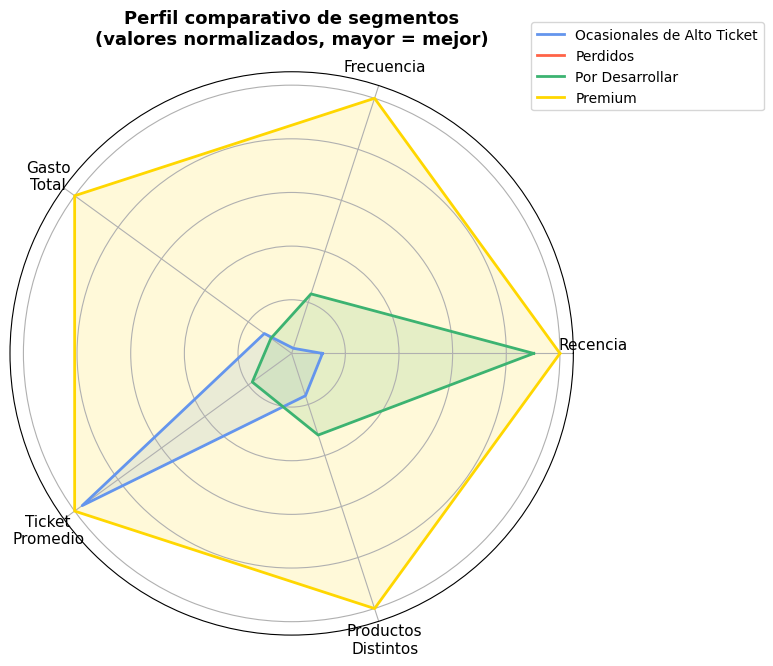

In [48]:
# Radar chart de perfiles
categorias = ['Recencia\n', 'Frecuencia', 'Gasto\nTotal',
              'Ticket\nPromedio', 'Productos\nDistintos']
N = len(categorias)

centroides = perfil_clientes.groupby('NOMBRE_CLUSTER')[cols_perfil].mean()

# Normalizar entre 0 y 1 — invertir recencia para que "mejor" sea más alto
from sklearn.preprocessing import MinMaxScaler
scaler_r = MinMaxScaler()
centroides_norm = pd.DataFrame(
    scaler_r.fit_transform(centroides),
    index=centroides.index, columns=cols_perfil
)
centroides_norm['DIAS_ULTIMA_COMPRA'] = 1 - centroides_norm['DIAS_ULTIMA_COMPRA']

angulos = [n / float(N) * 2 * np.pi for n in range(N)]
angulos += angulos[:1]

colores_radar = {'Premium': 'gold', 'Perdidos': 'tomato',
                 'Ocasionales de Alto Ticket': 'cornflowerblue',
                 'Por Desarrollar': 'mediumseagreen'}

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

for segmento, row in centroides_norm.iterrows():
    valores = row.tolist() + [row.tolist()[0]]
    ax.plot(angulos, valores, linewidth=2, label=segmento,
            color=colores_radar[segmento])
    ax.fill(angulos, valores, alpha=0.15, color=colores_radar[segmento])

ax.set_xticks(angulos[:-1])
ax.set_xticklabels(categorias, fontsize=11)
ax.set_yticklabels([])
ax.set_title('Perfil comparativo de segmentos\n(valores normalizados, mayor = mejor)',
             fontsize=13, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1), fontsize=10)

plt.tight_layout()
plt.show()

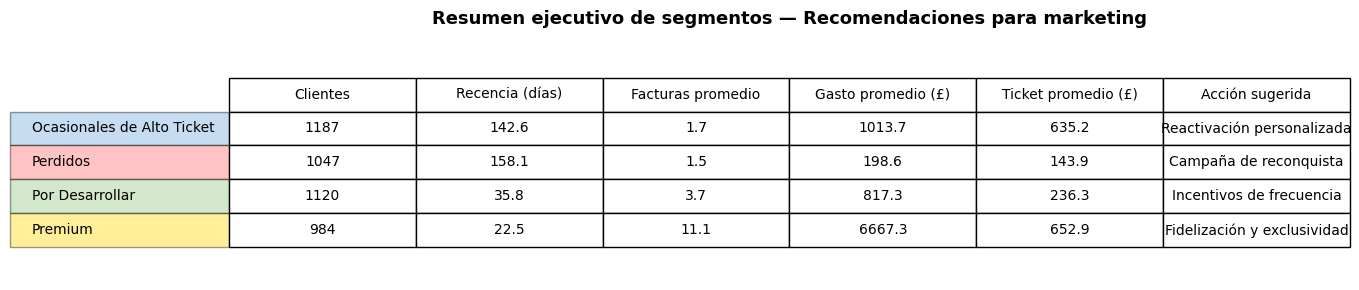

In [49]:
#Tabla resumen para marketing
resumen_final = perfil_clientes.groupby('NOMBRE_CLUSTER').agg(
    Clientes       = ('CLUSTER', 'count'),
    Recencia_dias  = ('DIAS_ULTIMA_COMPRA', 'mean'),
    Frecuencia     = ('CANT_FACTURAS', 'mean'),
    Gasto_total    = ('GASTO_TOTAL', 'mean'),
    Ticket         = ('TICKET_PROMEDIO', 'mean')
).round(1)

resumen_final.columns = ['Clientes', 'Recencia (días)',
                          'Facturas promedio', 'Gasto promedio (£)',
                          'Ticket promedio (£)']

acciones = {
    'Ocasionales de Alto Ticket': 'Reactivación personalizada',
    'Perdidos':                  'Campaña de reconquista',
    'Por Desarrollar':           'Incentivos de frecuencia',
    'Premium':                   'Fidelización y exclusividad'
}
resumen_final['Acción sugerida'] = [acciones[s] for s in resumen_final.index]

fig, ax = plt.subplots(figsize=(14, 3))
ax.axis('off')

tabla = ax.table(
    cellText=resumen_final.values,
    colLabels=resumen_final.columns,
    rowLabels=resumen_final.index,
    cellLoc='center',
    loc='center'
)
tabla.auto_set_font_size(False)
tabla.set_fontsize(10)
tabla.scale(1.2, 2)

colores_filas = {
    'Premium': 'gold',
    'Perdidos': '#ff6b6b',
    'Ocasionales de Alto Ticket': '#6fa8dc',
    'Por Desarrollar': '#93c47d'
}
for i, seg in enumerate(resumen_final.index):
    tabla[i+1, -1].set_facecolor(colores_filas[seg])
    tabla[i+1, -1].set_alpha(0.4)

ax.set_title('Resumen ejecutivo de segmentos — Recomendaciones para marketing',
             fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

###Resultados DBSCAN

Se entrenó DBSCAN con eps=0.7 y min_samples=5, parámetros seleccionados mediante grilla de búsqueda evaluando silueta y porcentaje de ruido. El modelo detectó 2 clusters y clasificó 30 clientes (0.7%) como ruido. El coeficiente de silueta fue de 0.4479, calculado sobre los puntos no clasificados como ruido.

Entre los clientes clasificados como ruido, **DBSCAN identificó 11 hiper mayoristas** que operan en una escala cualitativamente distinta al resto de la base. K-Means los había absorbido dentro del segmento Premium, diluyendo su perfil real.

## Elección del modelo final: K-Means

In [50]:
comparacion = pd.DataFrame({
    'Métrica': [
        'Número de clusters',
        'Coeficiente de silueta',
        'Requiere definir K',
        'Clientes sin asignar',
        'Distribución equilibrada',
        'Detecta atípicos'
    ],
    'K-Means': [
        str(kmeans.n_clusters),
        f"{silhouette_score(perfil_scaled, kmeans.labels_):.4f}",
        'Sí',
        '0 (0.0%)',
        'Sí',
        'No'
    ],
    'DBSCAN': [
        str(len(set(labels)) - (1 if -1 in labels else 0)),
        f"{silhouette_score(perfil_scaled[labels != -1], labels[labels != -1]):.4f}",
        'No',
        f"{(labels == -1).sum()} ({(labels == -1).sum()/len(labels)*100:.1f}%)",
        'No',
        'Sí'
    ]
})

display(comparacion)

,Métrica,K-Means,DBSCAN
0,Número de clusters,4,2
1,Coeficiente de silueta,0.2511,0.4479
2,Requiere definir K,Sí,No
3,Clientes sin asignar,0 (0.0%),30 (0.7%)
4,Distribución equilibrada,Sí,No
5,Detecta atípicos,No,Sí


La tabla resume las diferencias fundamentales entre ambos modelos.

K-Means obtuvo una silueta de 0.2511 contra 0.4479 de DBSCAN — aparentemente DBSCAN gana. Sin embargo, esa métrica se calcula sobre 2 clusters contra 4, lo que hace la comparación asimétrica: es más fácil obtener silueta alta con pocos clusters bien separados que con muchos.

Lo que la tabla no muestra es el contenido de esos clusters. Los 2 grupos de DBSCAN dividen la base en "activos" e "inactivos" — una distinción útil pero insuficiente para diseñar campañas diferenciadas.

Los 4 grupos de K-Means permiten acciones distintas para cada perfil, brindando al equipo de marketing una forma específica sobre cada grupo.

Por eso elegimos K-Means como modelo final, priorizando utilidad para el negocio sobre métrica de calidad.


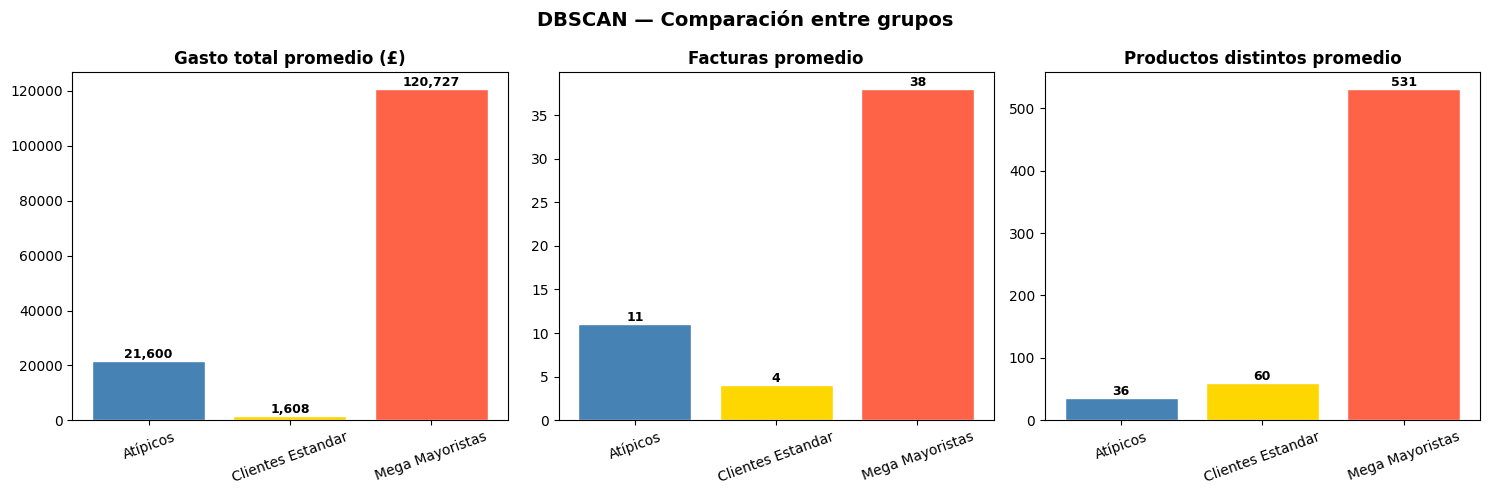

In [52]:
# Comparación de escala entre grupos DBSCAN
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('DBSCAN — Comparación entre grupos', fontsize=14, fontweight='bold')

metricas = ['GASTO_TOTAL', 'CANT_FACTURAS', 'PRODUCTOS_DISTINTOS']
titulos  = ['Gasto total promedio (£)', 'Facturas promedio', 'Productos distintos promedio']
nombres = resumen_db.index.tolist()
palette = ['steelblue', 'gold', 'tomato', 'black']
colores = {nombre: color for nombre, color in zip(nombres, palette)}
resumen_db = perfil_clientes.groupby('NOMBRE_CLUSTER_DBSCAN')[metricas].mean().round(0)

for i, (col, titulo) in enumerate(zip(metricas, titulos)):
    bars = axes[i].bar(resumen_db.index, resumen_db[col],
                       color=[colores[s] for s in resumen_db.index],
                       edgecolor='white')
    axes[i].set_title(titulo, fontweight='bold')
    axes[i].tick_params(axis='x', rotation=20)
    for bar, val in zip(bars, resumen_db[col]):
        axes[i].annotate(f'{val:,.0f}',
                         (bar.get_x() + bar.get_width()/2, bar.get_height()),
                         ha='center', va='bottom', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()

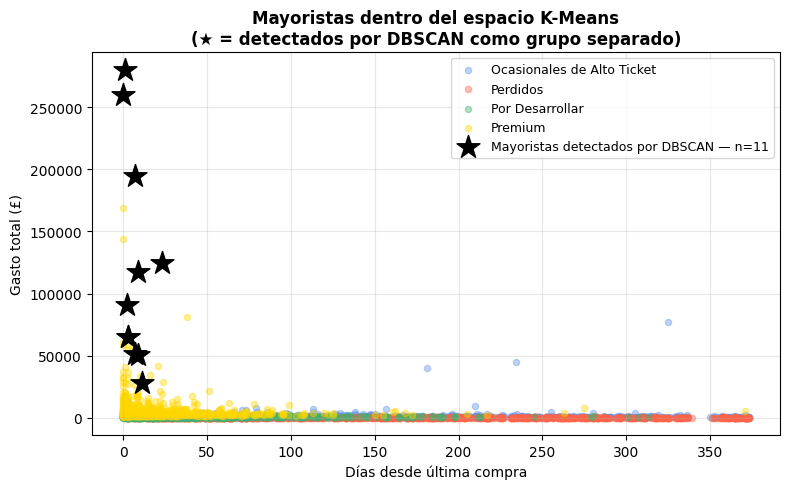

In [53]:
# Dónde caen los mayoristas dentro de los clusters de K-Means
mayoristas = perfil_clientes[perfil_clientes['NOMBRE_CLUSTER_DBSCAN'] == 'Mega Mayoristas']

fig, ax = plt.subplots(figsize=(8, 5))

colores_km = {
    'Premium': 'gold', 'Perdidos': 'tomato',
    'Ocasionales de Alto Ticket': 'cornflowerblue', 'Por Desarrollar': 'mediumseagreen'
}

for segmento, grupo in perfil_clientes.groupby('NOMBRE_CLUSTER'):
    ax.scatter(grupo['DIAS_ULTIMA_COMPRA'], grupo['GASTO_TOTAL'],
               color=colores_km[segmento], alpha=0.4, s=20, label=segmento)

ax.scatter(mayoristas['DIAS_ULTIMA_COMPRA'], mayoristas['GASTO_TOTAL'],
           color='black', s=300, zorder=5, marker='*',
           label=f'Mayoristas detectados por DBSCAN — n={len(mayoristas)}')

ax.set_xlabel('Días desde última compra')
ax.set_ylabel('Gasto total (£)')
ax.set_title('Mayoristas dentro del espacio K-Means\n(★ = detectados por DBSCAN como grupo separado)',
             fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

El gráfico muestra todos los clientes en el espacio de K-Means (recencia vs. gasto total), con las estrellas negras marcando los 11 clientes que DBSCAN identificó como grupo separado.

Lo primero que salta a la vista es que los 11 mayoristas están todos concentrados en la zona de recencia baja (compraron hace poco) y gasto muy alto — claramente por encima del resto de la base.

K-Means los absorbió dentro del segmento Premium porque comparten esas dos características con ese grupo, pero su escala de gasto es cualitativamente distinta: mientras un cliente Premium típico gasta entre £5.000 y £20.000, estos 11 clientes superan los £50.000 y algunos llegan a £280.000.

Esto ilustra una limitación estructural de K-Means: al forzar una partición en K grupos, asigna cada punto al centroide más cercano aunque ese punto sea un outlier extremo.

DBSCAN en cambio los detecta como una región de densidad propia y los separa automáticamente. Para el equipo de marketing, esto tiene una implicación concreta: *estos 11 clientes no deberían recibir las mismas comunicaciones que el resto del segmento Premium — merecen una gestión de cuenta individualizada.*

###Interpretación de los clusters

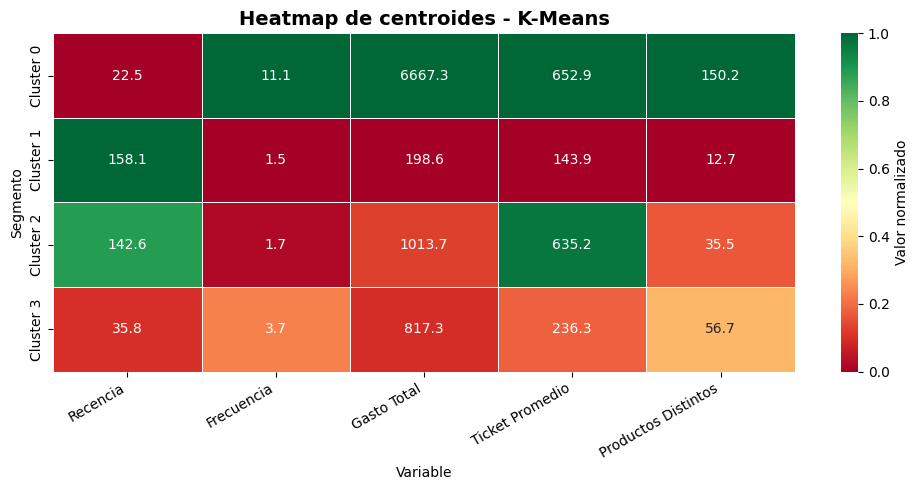

In [54]:
# Calcular medias por cluster con valores reales
centroides = perfil_clientes.groupby('CLUSTER')[cols_perfil].mean()

centroides.index = [f'Cluster {i}' for i in centroides.index]

# Normalizar entre 0 y 1 para que todas las variables sean comparables
scaler_viz = MinMaxScaler()
centroides_norm = pd.DataFrame(
    scaler_viz.fit_transform(centroides),
    index=centroides.index,
    columns=cols_perfil
)

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(
    centroides_norm,
    annot=centroides.round(1),
    fmt='g',
    cmap='RdYlGn',
    linewidths=0.5,
    ax=ax,
    cbar_kws={'label': 'Valor normalizado'}
)

ax.set_title('Heatmap de centroides - K-Means', fontsize=14, fontweight='bold')
ax.set_xlabel('Variable')
ax.set_ylabel('Segmento')
ax.set_xticklabels(
    ['Recencia', 'Frecuencia', 'Gasto Total', 'Ticket Promedio', 'Productos Distintos'],
    rotation=30,
    ha='right'
)

plt.tight_layout()
plt.show()

El heatmap resume en una sola visualización el perfil promedio de cada segmento.

El color representa el valor normalizado de cada variable (verde = alto, rojo = bajo), mientras que los números muestran los valores reales para facilitar la interpretación:

- **Cluster 0** es el único segmento completamente verde en Frecuencia, Gasto Total y Productos Distintos, confirmando que son los clientes más valiosos en todas las dimensiones simultáneamente.

- **Cluster 1** es el único segmento completamente rojo en todas las variables excepto Recencia, donde comparte el verde con el cluster siguiente. Esto refuerza que no es solo que no compren hace mucho, sino que cuando compraron tampoco gastaron ni exploraron demasiado.

- **Cluster 2** tiene un patrón interesante: verde en Recencia, llevan mucho tiempo sin comprar, pero verde también en Ticket Promedio (£635).
Son clientes que vale la pena reactivar porque cuando compran, gastan bien.

- **Cluster 3** es el segmento más equilibrado: valores medios en todo,
sin destacar ni caer en ninguna dimensión. Son el segmento con mayor potencial
de moverse hacia el cluster 0 con la estrategia correcta.

Lo que aporta este gráfico respecto a la tabla de medias es que permite comparar los segmentos entre sí de forma inmediata y visual, sin necesidad de leer números.
Es especialmente útil para la presentación al equipo de marketing.

Sumamos las métricas:

In [55]:
interpretacion = perfil_clientes.groupby('CLUSTER')[cols_perfil].mean().round(2)
interpretacion

,DIAS_ULTIMA_COMPRA,CANT_FACTURAS,GASTO_TOTAL,TICKET_PROMEDIO,PRODUCTOS_DISTINTOS
CLUSTER,,,,,
0,22.52,11.06,6667.32,652.88,150.18
1,158.15,1.47,198.62,143.94,12.72
2,142.59,1.66,1013.67,635.19,35.54
3,35.80,3.70,817.31,236.29,56.71


**Cluster 0 — Clientes Premium**

>Compraron hace muy poco, con alta frecuencia, gasto total muy alto, ticket promedio alto y gran variedad de productos. Son los mejores clientes de la
plataforma: activos, fieles y de alto valor económico.

- **Acción de marketing:** programas de fidelización, acceso anticipado
a nuevos productos, descuentos exclusivos.

**Cluster 1 — Clientes Perdidos**

>Llevan mucho tiempo sin comprar, compraron muy pocas veces, gastaron poco y exploraron pocos productos.
Son clientes que probaron la plataforma y no volvieron.

- **Acción de marketing:** campañas de reactivación agresivas, descuentos
de bienvenida de vuelta, recordatorios personalizados.

**Cluster 2 — Clientes Ocasionales de Alto Ticket**

>Llevan tiempo sin comprar pero cuando compraron gastaron
bastante por factura. Compraron pocas veces y poca variedad. Son clientes que tuvieron una o dos compras importantes y desaparecieron.

- **Acción de marketing:** campañas de reactivación enfocadas en productos
similares a los que ya compraron, ofertas personalizadas de alto valor.

**Cluster 3 — Clientes por Desarrollar**

>Compraron hace poco, con frecuencia moderada,
gasto moderado y variedad media. Son clientes activos pero con potencial de crecer.

- **Acción de marketing:** incentivar la frecuencia de compra,
recomendaciones de productos nuevos, descuentos por volumen.

## Conclusiones

El objetivo del trabajo fue segmentar la base de clientes para que el equipo de
marketing pudiera abandonar las campañas masivas indiferenciadas y diseñar
estrategias específicas por perfil.

Consideramos que ese objetivo se cumplió: partiendo de un dataset crudo de
aproximadamente 500.000 líneas de transacción, construimos un perfil de
comportamiento para 4.338 clientes únicos y obtuvimos una segmentación
accionable en cuatro grupos.

El modelo final (K-Means con K=4) identificó los segmentos **Premium**,
**Perdidos**, **Ocasionales de Alto Ticket** y **Por Desarrollar**. Los números
hablan por sí solos:

- El segmento **Premium** representa apenas el 22% de los clientes (984) pero
concentra el **73% de la facturación total** (£6.560.645 sobre £8.887.209).
Su gasto promedio de £6.667 por cliente es 33 veces mayor que el de los Perdidos.

- El segmento **Perdidos** (1.047 clientes) generó apenas £207.959 en total.
Son clientes recuperables: si una campaña de reactivación lograra que el 10%
vuelva a comprar al nivel de Por Desarrollar (£817 promedio), significaría
aproximadamente £85.000 de facturación adicional.

- Los **Ocasionales de Alto Ticket** (1.187 clientes) gastaron £1.014 promedio
por cliente pero llevan más de 140 días sin comprar. Son el segmento con mayor
potencial de reactivación dado su ticket alto.

- Los **Por Desarrollar** (1.120 clientes) están activos y tienen margen de
crecimiento: si su gasto promedio (£817) creciera un 30%, aportarían £274.000
adicionales a la facturación.

DBSCAN reveló además 11 mega mayoristas con gasto medio de £120.727 que K-Means
había absorbido dentro del segmento Premium. Estos 11 clientes solos representan
aproximadamente £1.328.000 en facturación y merecen una gestión de cuenta
individualizada, completamente separada de cualquier campaña automatizada.

*Limitaciones del análisis*

Los segmentos obtenidos representan únicamente a los clientes registrados en la plataforma.

El 25% de las transacciones correspondía a compradores sin CustomerID y quedó fuera del análisis.

Adicionalmente, el dataset cubre un período de 12 meses (2010–2011). Los segmentos reflejan el comportamiento en ese período específico y deberían actualizarse periódicamente a medida que nuevas transacciones ingresen al sistema.
